# Deliverables Machine learning project

## Step-by-Step analysis

### 1. Setting Up the Environment

In [87]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import tarfile
import os
import glob
import missingno as msno
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import plotly.express as px
import folium
from folium.plugins import MarkerCluster, HeatMap
import plotly.graph_objects as go
import dash
from dash import dcc, html
from dash.dependencies import Input, Output
from functools import reduce

#### Configuring display settings

In [88]:
# Configuring display settings
plt.rcParams['figure.figsize'] = (12, 9)
sns.set()
sns.set_context('talk')
np.set_printoptions(threshold=500, precision=2, suppress=True)
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 2)
pd.set_option('display.float_format', '{:.2f}'.format)
warnings.filterwarnings("ignore", category=FutureWarning)

### 2. Loading and Exploring the Housing Data

In [89]:
directory_path = "."
search_pattern = os.path.join(directory_path, "*.csv")
csv_files_names = glob.glob(search_pattern)

if not csv_files_names:
    print("Error: No CSV files found in the specified directory.")
else:
    first_file = csv_files_names[0]
    employees_data = pd.read_csv(first_file)
    print(f"Loaded initial file: {os.path.basename(first_file)}")
    
    for next_file in csv_files_names[1:]:
        next_df = pd.read_csv(next_file)
        employees_data = pd.merge(
            employees_data,
            next_df,
            on="EmployeeID",
            how='outer',
            suffixes=('', f'_{os.path.basename(next_file).replace(".csv", "")}')
        )
        print(f'Merged with: {os.path.basename(next_file)}')
    print("\n--- Merged DataFrame Information (Joined on EmployeeID) ---")

Loaded initial file: employee_survey_data.csv
Merged with: general_data.csv
Merged with: manager_survey_data.csv

--- Merged DataFrame Information (Joined on EmployeeID) ---


### 3. Understanding the Data

#### Data infos

In [90]:
print(employees_data.info())
print('number of columns:', employees_data.columns.nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   EmployeeID               4410 non-null   int64  
 1   EnvironmentSatisfaction  4385 non-null   float64
 2   JobSatisfaction          4390 non-null   float64
 3   WorkLifeBalance          4372 non-null   float64
 4   Age                      4410 non-null   int64  
 5   Attrition                4410 non-null   object 
 6   BusinessTravel           4410 non-null   object 
 7   Department               4410 non-null   object 
 8   DistanceFromHome         4410 non-null   int64  
 9   Education                4410 non-null   int64  
 10  EducationField           4410 non-null   object 
 11  EmployeeCount            4410 non-null   int64  
 12  Gender                   4410 non-null   object 
 13  JobLevel                 4410 non-null   int64  
 14  JobRole                 

In [91]:
# 1. Identify constant columns (noise)
# We look for columns where the number of unique values is exactly 1
constant_columns = [col for col in employees_data.columns if employees_data[col].nunique() <= 1]

print(f"Constant columns to drop: {constant_columns}")

# 2. Identify potentially unethical/sensitive columns
# We define a list of keywords usually associated with bias or privacy
sensitive_keywords = [
    'gender', 'sex', 'religion', 'race', 'ethnicity', 
    'political', 'union', 'disability', 'sexual', 'birth'
]

# We check if any column name contains one of these keywords
sensitive_columns = [
    col for col in employees_data.columns 
    if any(keyword in col.lower() for keyword in sensitive_keywords)
]

print(f"Sensitive columns detected: {sensitive_columns}")

# 3. Combine and drop
# We verify if we found columns to drop before executing the action
columns_to_drop = constant_columns + sensitive_columns

if columns_to_drop:
    employees_data = employees_data.drop(columns=columns_to_drop)
    print("Columns successfully dropped.")
else:
    print("No columns to drop found.")

# Display new shape
print('New data shape:', employees_data.shape)

Constant columns to drop: ['EmployeeCount', 'Over18', 'StandardHours']
Sensitive columns detected: ['Gender']
Columns successfully dropped.
New data shape: (4410, 25)


#### Data description

In [92]:
employees_data.describe()

,EmployeeID,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,Age,DistanceFromHome,Education,JobLevel,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager,JobInvolvement,PerformanceRating
count,4410.00,4385.00,4390.00,4372.00,4410.00,4410.00,4410.00,4410.00,4410.00,4391.00,4410.00,4410.00,4401.00,4410.00,4410.00,4410.00,4410.00,4410.00,4410.00
mean,2205.50,2.72,2.73,2.76,36.92,9.19,2.91,2.06,65029.31,2.69,15.21,0.79,11.28,2.80,7.01,2.19,4.12,2.73,3.15
std,1273.20,1.09,1.10,0.71,9.13,8.11,1.02,1.11,47068.89,2.50,3.66,0.85,7.78,1.29,6.13,3.22,3.57,0.71,0.36
min,1.00,1.00,1.00,1.00,18.00,1.00,1.00,1.00,10090.00,0.00,11.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,3.00
25%,1103.25,2.00,2.00,2.00,30.00,2.00,2.00,1.00,29110.00,1.00,12.00,0.00,6.00,2.00,3.00,0.00,2.00,2.00,3.00
50%,2205.50,3.00,3.00,3.00,36.00,7.00,3.00,2.00,49190.00,2.00,14.00,1.00,10.00,3.00,5.00,1.00,3.00,3.00,3.00
75%,3307.75,4.00,4.00,3.00,43.00,14.00,4.00,3.00,83800.00,4.00,18.00,1.00,15.00,3.00,9.00,3.00,7.00,3.00,3.00
max,4410.00,4.00,4.00,4.00,60.00,29.00,5.00,5.00,199990.00,9.00,25.00,3.00,40.00,6.00,40.00,15.00,17.00,4.00,4.00


#### Data head

In [93]:
employees_data.head()

,EmployeeID,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,JobLevel,JobRole,MaritalStatus,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager,JobInvolvement,PerformanceRating
0,1,3.00,4.00,2.00,51,No,Travel_Rarely,Sales,6,2,Life Sciences,1,Healthcare Representative,Married,131160,1.00,11,0,1.00,6,1,0,0,3,3
1,2,3.00,2.00,4.00,31,Yes,Travel_Frequently,Research & Development,10,1,Life Sciences,1,Research Scientist,Single,41890,0.00,23,1,6.00,3,5,1,4,2,4
2,3,2.00,2.00,1.00,32,No,Travel_Frequently,Research & Development,17,4,Other,4,Sales Executive,Married,193280,1.00,15,3,5.00,2,5,0,3,3,3
3,4,4.00,4.00,3.00,38,No,Non-Travel,Research & Development,2,5,Life Sciences,3,Human Resources,Married,83210,3.00,11,3,13.00,5,8,7,5,2,3
4,5,4.00,1.00,3.00,32,No,Travel_Rarely,Research & Development,10,1,Medical,1,Sales Executive,Single,23420,4.00,12,2,9.00,2,6,0,4,3,3


#### What does the columns contains ?

In [94]:
for col in employees_data.columns:
    print("Name of the column", col)
    print(employees_data[col].value_counts())
    print("-------------------------------------")

Name of the column EmployeeID
EmployeeID
1       1
2       1
3       1
4       1
5       1
       ..
4406    1
4407    1
4408    1
4409    1
4410    1
Name: count, Length: 4410, dtype: int64
-------------------------------------
Name of the column EnvironmentSatisfaction
EnvironmentSatisfaction
3.00    1350
4.00    1334
2.00     856
1.00     845
Name: count, dtype: int64
-------------------------------------
Name of the column JobSatisfaction
JobSatisfaction
4.00    1367
3.00    1323
1.00     860
2.00     840
Name: count, dtype: int64
-------------------------------------
Name of the column WorkLifeBalance
WorkLifeBalance
3.00    2660
2.00    1019
4.00     454
1.00     239
Name: count, dtype: int64
-------------------------------------
Name of the column Age
Age
35    234
34    231
31    207
36    207
29    204
32    183
30    180
33    174
38    174
40    171
37    150
27    144
28    144
42    138
39    126
45    123
41    120
26    117
46     99
44     99
43     96
50     90
25     

### 4. Handling Missing values

#### Visualize missing data

In [95]:
employees_data.isnull().sum()

EmployeeID                  0
EnvironmentSatisfaction    25
JobSatisfaction            20
WorkLifeBalance            38
Age                         0
Attrition                   0
BusinessTravel              0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
JobLevel                    0
JobRole                     0
MaritalStatus               0
MonthlyIncome               0
NumCompaniesWorked         19
PercentSalaryHike           0
StockOptionLevel            0
TotalWorkingYears           9
TrainingTimesLastYear       0
YearsAtCompany              0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
JobInvolvement              0
PerformanceRating           0
dtype: int64

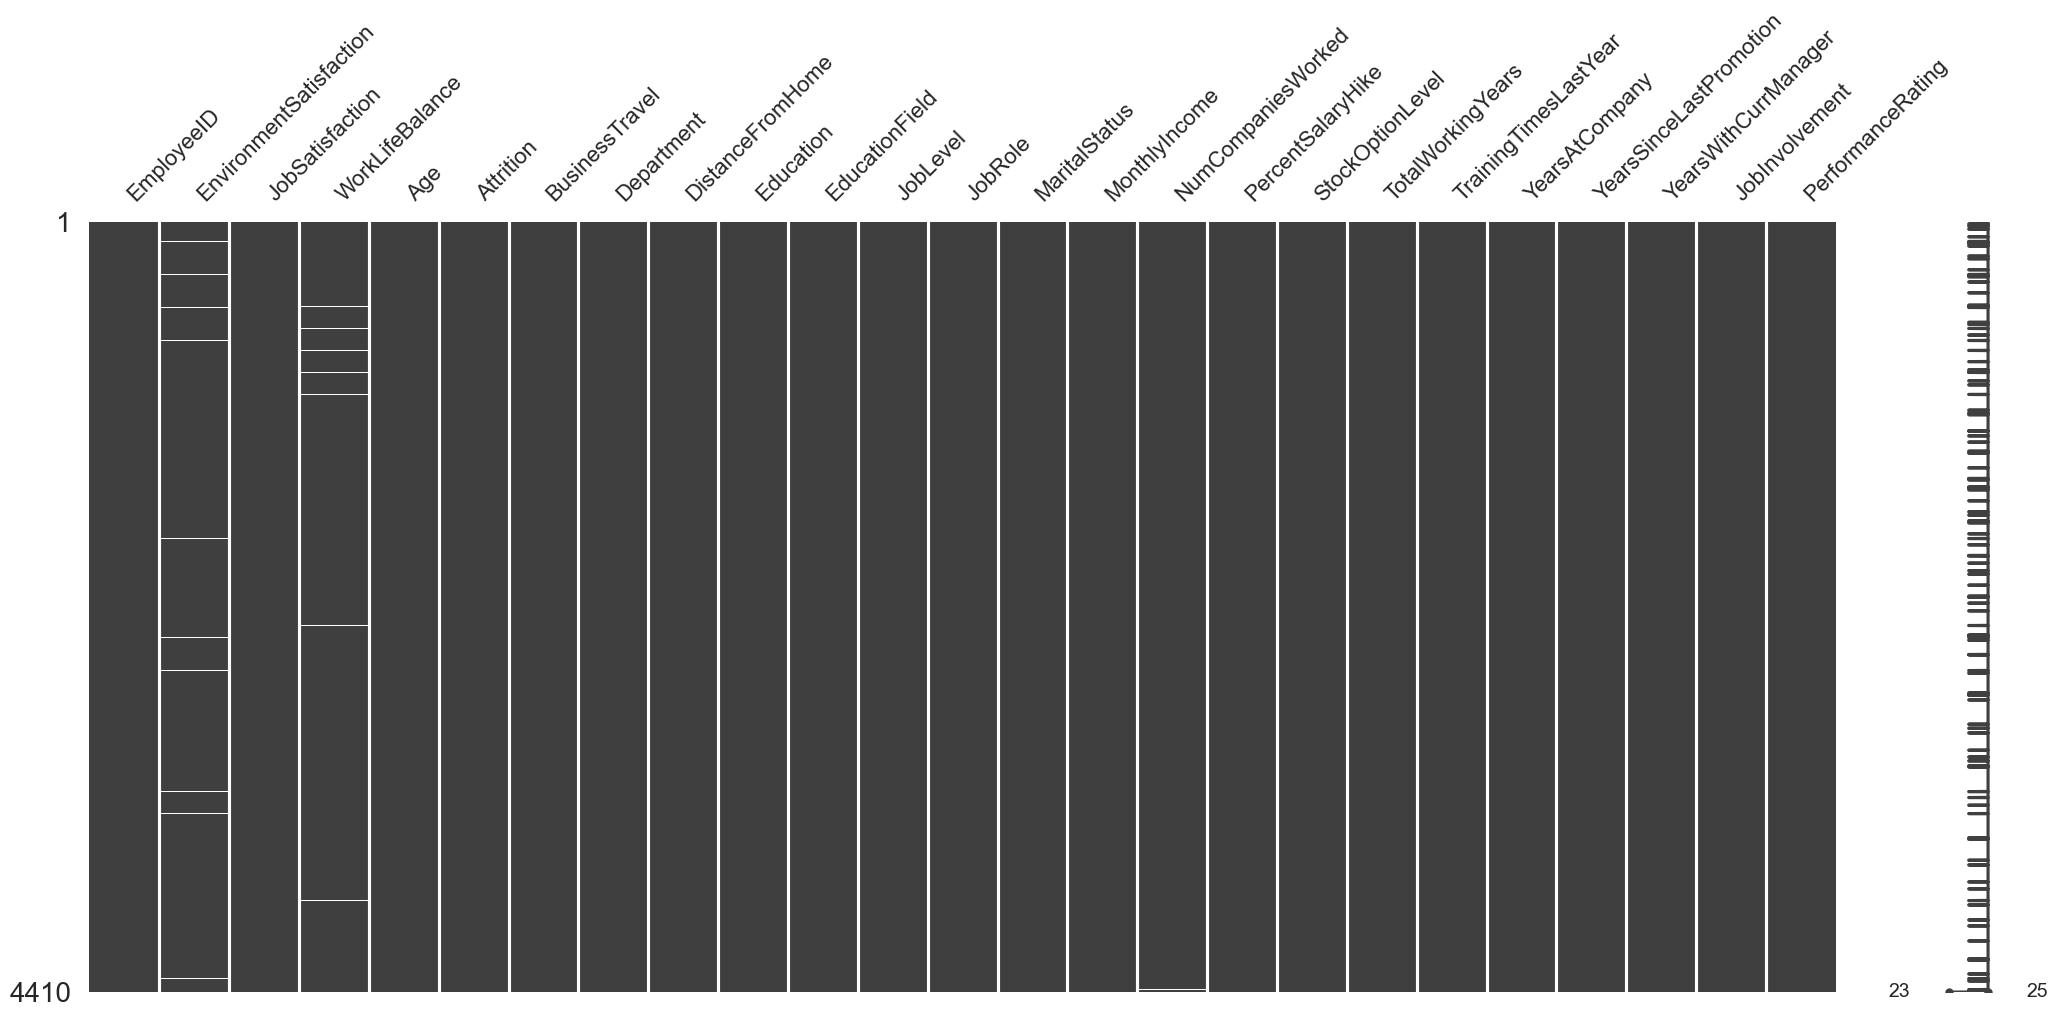

In [96]:
msno.matrix(employees_data)
plt.show()

#### Impute missing values

##### For numerical columns, use median imputation

In [97]:
numerical_cols = employees_data.select_dtypes(include=['int64', 'float64']).columns
employees_data[numerical_cols] = employees_data[numerical_cols].fillna(employees_data[numerical_cols].median())

##### For categorical columns, use mode imputation

In [98]:
categorical_cols = employees_data.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if employees_data[col].isnull().sum() > 0:
        mode_value = employees_data[col].mode()
        if len(mode_value) > 0:
            employees_data[col].fillna(mode_value[0], inplace=True)
        else:
            employees_data[col].fillna('Unknown', inplace=True)

##### Verifying that there are no more missing values

In [99]:
employees_data.isnull().sum()

EmployeeID                 0
EnvironmentSatisfaction    0
JobSatisfaction            0
WorkLifeBalance            0
Age                        0
Attrition                  0
BusinessTravel             0
Department                 0
DistanceFromHome           0
Education                  0
EducationField             0
JobLevel                   0
JobRole                    0
MaritalStatus              0
MonthlyIncome              0
NumCompaniesWorked         0
PercentSalaryHike          0
StockOptionLevel           0
TotalWorkingYears          0
TrainingTimesLastYear      0
YearsAtCompany             0
YearsSinceLastPromotion    0
YearsWithCurrManager       0
JobInvolvement             0
PerformanceRating          0
dtype: int64

### 4.5. Detecting and Removing Duplicates

In [100]:
# Check for duplicate rows
duplicate_count = employees_data.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

if duplicate_count > 0:
    print(f"\nRemoving {duplicate_count} duplicate rows...")
    employees_data = employees_data.drop_duplicates()
    print(f"New data shape after removing duplicates: {employees_data.shape}")
else:
    print("No duplicate rows found.")

Number of duplicate rows: 0
No duplicate rows found.


### 4.6. Detecting and Handling Outliers (IQR Method)

In [101]:
# Identify outliers using the IQR method
print("Detecting outliers using IQR method...\n")

numerical_cols = employees_data.select_dtypes(include=['int64', 'float64']).columns
outlier_indices = set()

for col in numerical_cols:
    Q1 = employees_data[col].quantile(0.25)
    Q3 = employees_data[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    col_outliers = ((employees_data[col] < lower_bound) | (employees_data[col] > upper_bound)).sum()
    if col_outliers > 0:
        print(f"{col}: {col_outliers} outliers detected (bounds: [{lower_bound:.2f}, {upper_bound:.2f}])")
        outlier_indices.update(employees_data[(employees_data[col] < lower_bound) | (employees_data[col] > upper_bound)].index)

print(f"\nTotal unique rows with outliers: {len(outlier_indices)}")

# Cap outliers at the boundary values instead of removing them (preserves data)
for col in numerical_cols:
    Q1 = employees_data[col].quantile(0.25)
    Q3 = employees_data[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    employees_data[col] = employees_data[col].clip(lower=lower_bound, upper=upper_bound)

print("Outliers have been capped to their boundary values.")

Detecting outliers using IQR method...

MonthlyIncome: 342 outliers detected (bounds: [-52925.00, 165835.00])
NumCompaniesWorked: 156 outliers detected (bounds: [-3.50, 8.50])
StockOptionLevel: 255 outliers detected (bounds: [-1.50, 2.50])
TotalWorkingYears: 189 outliers detected (bounds: [-7.50, 28.50])
TrainingTimesLastYear: 714 outliers detected (bounds: [0.50, 4.50])
YearsAtCompany: 312 outliers detected (bounds: [-6.00, 18.00])
YearsSinceLastPromotion: 321 outliers detected (bounds: [-4.50, 7.50])
YearsWithCurrManager: 42 outliers detected (bounds: [-5.50, 14.50])
PerformanceRating: 678 outliers detected (bounds: [3.00, 3.00])

Total unique rows with outliers: 2124
Outliers have been capped to their boundary values.


### 4.7. Re-checking and Removing True Constant Columns

In [102]:
# Re-check for true constant columns (those with only 1 unique value)
true_constant_cols = [col for col in employees_data.columns 
                      if employees_data[col].nunique() == 1]

print(f"Constant columns (only 1 unique value) found: {true_constant_cols}")

if true_constant_cols:
    print(f"\nRemoving constant columns: {true_constant_cols}")
    employees_data = employees_data.drop(columns=true_constant_cols)
    print(f"New shape after removing constant columns: {employees_data.shape}")
else:
    print("No constant columns found.")

Constant columns (only 1 unique value) found: ['PerformanceRating']

Removing constant columns: ['PerformanceRating']
New shape after removing constant columns: (4410, 24)


### 4.8. Encoding Categorical Features

In [103]:
# Identify categorical columns again (after dropping constant columns)
categorical_cols = employees_data.select_dtypes(include=['object']).columns.tolist()
numerical_cols = employees_data.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Categorical columns to encode: {categorical_cols}")
print(f"Numerical columns: {numerical_cols}\n")

# Apply One-Hot Encoding to categorical variables
if categorical_cols:
    print("Applying One-Hot Encoding...")
    # Drop EmployeeID before encoding (it's an identifier, not a feature)
    if 'EmployeeID' in employees_data.columns:
        employees_data_encoded = employees_data.drop(columns=['EmployeeID'])
    else:
        employees_data_encoded = employees_data.copy()
    
    # One-hot encode categorical columns
    employees_data_encoded = pd.get_dummies(employees_data_encoded, 
                                            columns=categorical_cols, 
                                            drop_first=True)
    
    print(f"Shape after encoding: {employees_data_encoded.shape}")
    print(f"New columns: {employees_data_encoded.columns.tolist()}\n")
else:
    employees_data_encoded = employees_data.copy()
    
print("One-Hot Encoding completed successfully.")

Categorical columns to encode: ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus']
Numerical columns: ['EmployeeID', 'EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance', 'Age', 'DistanceFromHome', 'Education', 'JobLevel', 'MonthlyIncome', 'NumCompaniesWorked', 'PercentSalaryHike', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'JobInvolvement']

Applying One-Hot Encoding...
Shape after encoding: (4410, 37)
New columns: ['EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance', 'Age', 'DistanceFromHome', 'Education', 'JobLevel', 'MonthlyIncome', 'NumCompaniesWorked', 'PercentSalaryHike', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'JobInvolvement', 'Attrition_Yes', 'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely', 'Department_Research 

### 4.9. Feature Scaling (Standardization)

In [104]:
# Standardize numerical features using StandardScaler
print("Applying StandardScaler to numerical features...\n")

# Create a copy for scaling
employees_data_scaled = employees_data_encoded.copy()

# Identify all numerical columns in the encoded dataset
numerical_cols_encoded = employees_data_scaled.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Initialize and fit the scaler
scaler = StandardScaler()
employees_data_scaled[numerical_cols_encoded] = scaler.fit_transform(employees_data_scaled[numerical_cols_encoded])

print(f"Scaled data shape: {employees_data_scaled.shape}")
print(f"\nSample of scaled data (first 5 rows):")
print(employees_data_scaled.head())
print(f"\nStatistics after scaling (should be approximately 0 mean and 1 std):")
print(employees_data_scaled[numerical_cols_encoded[:5]].describe())

Applying StandardScaler to numerical features...

Scaled data shape: (4410, 37)

Sample of scaled data (first 5 rows):
   EnvironmentSatisfaction  JobSatisfaction  WorkLifeBalance   Age  \
0                     0.25             1.16            -1.09  1.54   
1                     0.25            -0.66             1.76 -0.65   
2                    -0.67            -0.66            -2.51 -0.54   
3                     1.17             1.16             0.34  0.12   
4                     1.17            -1.57             0.34 -0.54   

   DistanceFromHome  Education  JobLevel  MonthlyIncome  NumCompaniesWorked  \
0             -0.39      -0.89     -0.96           1.55               -0.68   
1              0.10      -1.87     -0.96          -0.50               -1.09   
2              0.96       1.06      1.75           2.35               -0.68   
3             -0.89       2.04      0.85           0.45                0.13   
4              0.10      -1.87     -0.96          -0.92          

### 4.10. Final Data Quality Validation

In [105]:
print("="*60)
print("FINAL DATA PREPARATION VALIDATION REPORT")
print("="*60)

# Check 1: Missing Values
print("\n1. MISSING VALUES CHECK:")
missing_count = employees_data_scaled.isnull().sum().sum()
print(f"   Total missing values: {missing_count}")
if missing_count == 0:
    print("   ✓ PASS: No missing values found")
else:
    print(f"   ✗ FAIL: {missing_count} missing values detected")

# Check 2: Data Shape
print(f"\n2. DATA SHAPE:")
print(f"   Final shape: {employees_data_scaled.shape}")
print(f"   Rows: {employees_data_scaled.shape[0]}, Columns: {employees_data_scaled.shape[1]}")

# Check 3: Duplicates
print(f"\n3. DUPLICATE ROWS CHECK:")
duplicate_final = employees_data_scaled.duplicated().sum()
print(f"   Duplicate rows: {duplicate_final}")
if duplicate_final == 0:
    print("   ✓ PASS: No duplicate rows found")
else:
    print(f"   ✗ WARNING: {duplicate_final} duplicates detected")

# Check 4: Data Types
print(f"\n4. DATA TYPES:")
data_types = employees_data_scaled.dtypes.value_counts()
for dtype, count in data_types.items():
    print(f"   {dtype}: {count} columns")
print("   ✓ All columns are numeric (ready for ML)")

# Check 5: Feature Statistics
print(f"\n5. FEATURE STATISTICS (after scaling):")
numerical_cols_final = employees_data_scaled.select_dtypes(include=['int64', 'float64']).columns
print(f"   Total features: {len(numerical_cols_final)}")
print(f"   Mean of features (should be ~0): {employees_data_scaled[numerical_cols_final].mean().mean():.6f}")
print(f"   Std of features (should be ~1): {employees_data_scaled[numerical_cols_final].std().mean():.6f}")

# Check 6: Value Ranges
print(f"\n6. VALUE RANGES CHECK:")
has_nan = employees_data_scaled.isnull().any().any()
has_inf = np.isinf(employees_data_scaled.select_dtypes(include=['float64']).values).any()
print(f"   NaN values: {has_nan}")
print(f"   Infinite values: {has_inf}")
if not has_nan and not has_inf:
    print("   ✓ PASS: All values are valid")

print("\n" + "="*60)
print("✓ DATA PREPARATION COMPLETE AND VALIDATED")
print("✓ Data is ready for model building")
print("="*60)

# Summary statistics
print(f"\nPREPARED DATASET SUMMARY:")
print(f"- Total samples: {employees_data_scaled.shape[0]}")
print(f"- Total features: {employees_data_scaled.shape[1]}")
print(f"- Feature encoding: One-Hot (categorical), Standardized (numerical)")
print(f"- Missing values: None")
print(f"- Duplicates: None")
print(f"- Outliers: Capped using IQR method")

FINAL DATA PREPARATION VALIDATION REPORT

1. MISSING VALUES CHECK:
   Total missing values: 0
   ✓ PASS: No missing values found

2. DATA SHAPE:
   Final shape: (4410, 37)
   Rows: 4410, Columns: 37

3. DUPLICATE ROWS CHECK:
   Duplicate rows: 2866
   ✗ WARNING: 2866 duplicates detected

4. DATA TYPES:
   bool: 20 columns
   float64: 17 columns
   ✓ All columns are numeric (ready for ML)

5. FEATURE STATISTICS (after scaling):
   Total features: 17
   Mean of features (should be ~0): 0.000000
   Std of features (should be ~1): 1.000113

6. VALUE RANGES CHECK:
   NaN values: False
   Infinite values: False
   ✓ PASS: All values are valid

✓ DATA PREPARATION COMPLETE AND VALIDATED
✓ Data is ready for model building

PREPARED DATASET SUMMARY:
- Total samples: 4410
- Total features: 37
- Feature encoding: One-Hot (categorical), Standardized (numerical)
- Missing values: None
- Duplicates: None
- Outliers: Capped using IQR method


### 5. Univariate Analysis

#### Univariate analysis for numerical features

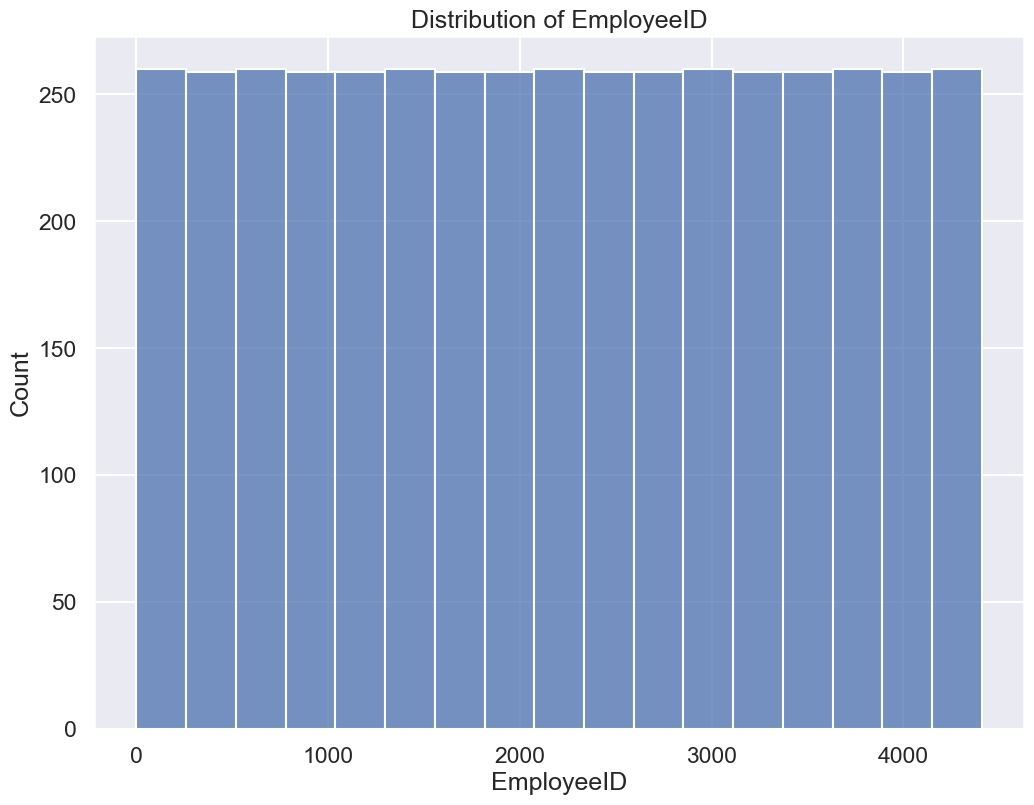

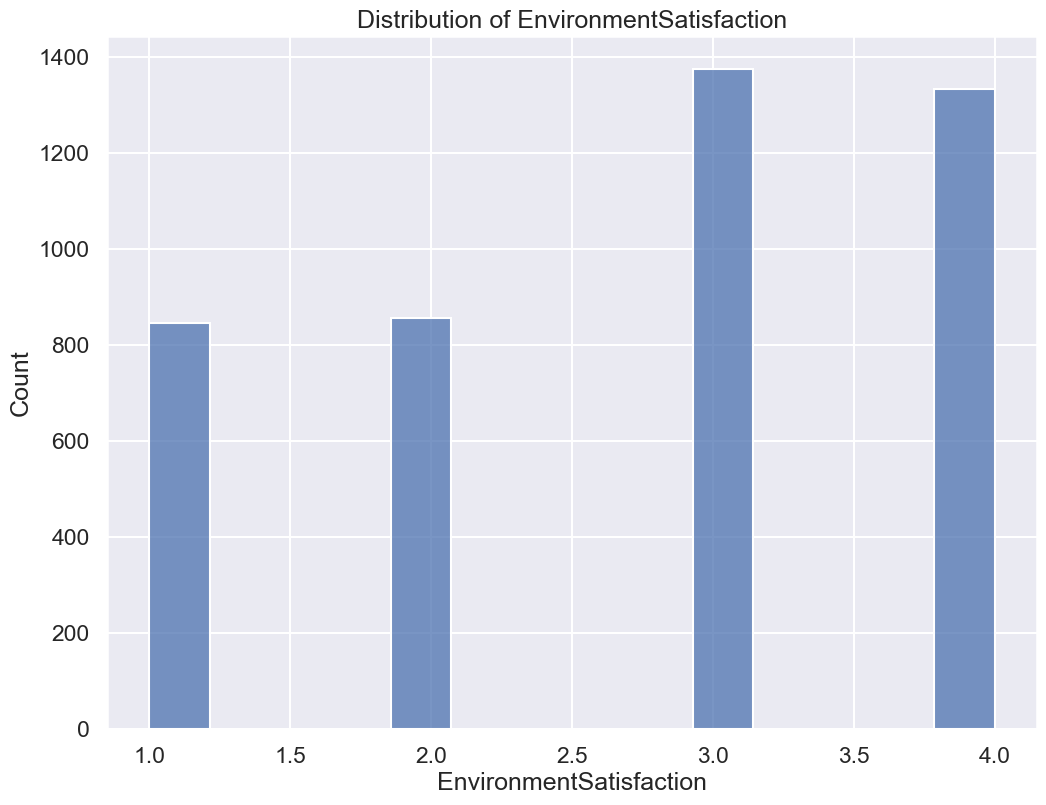

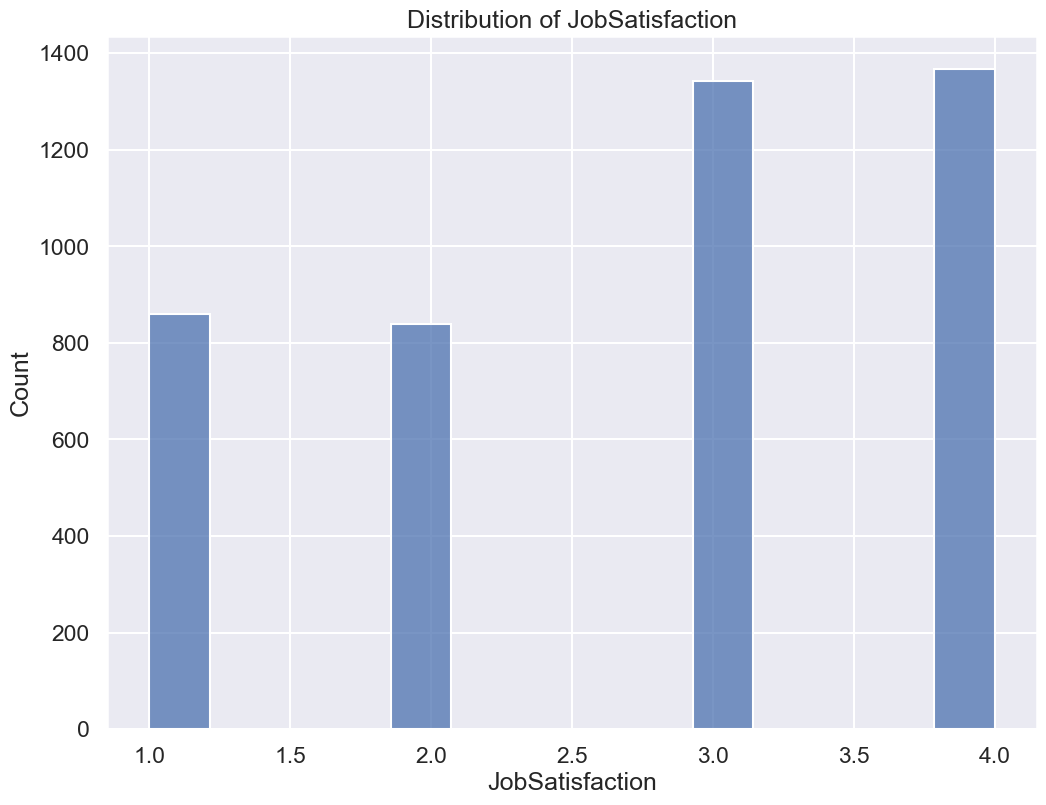

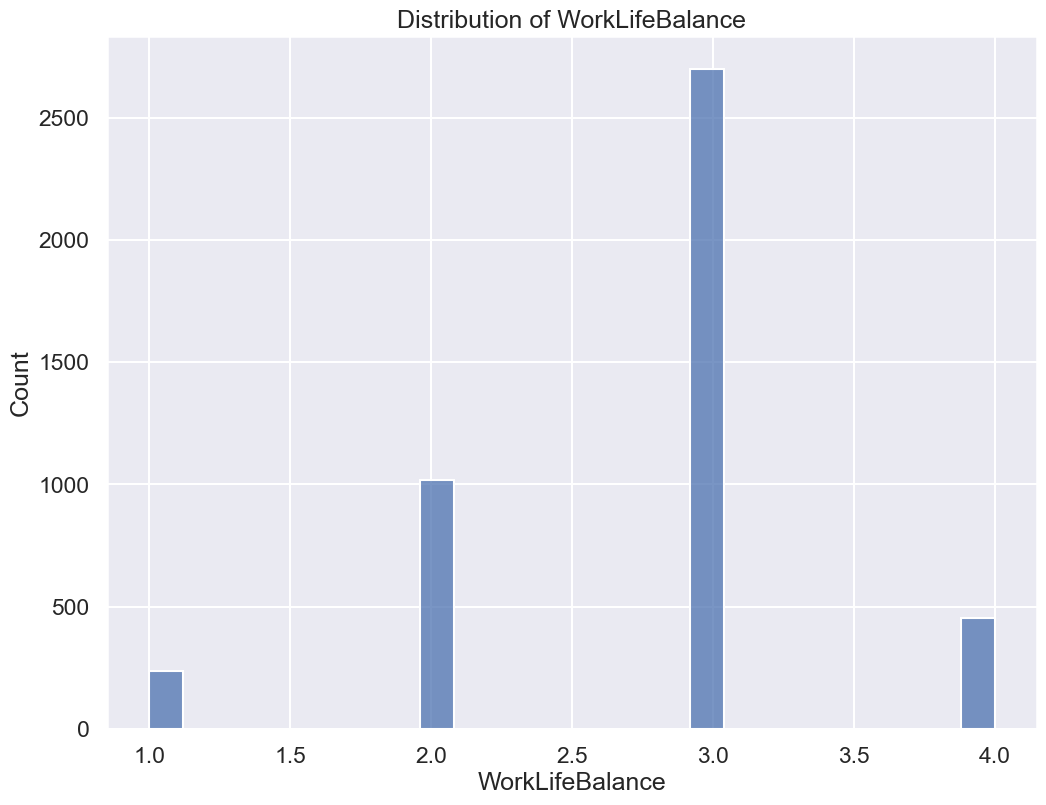

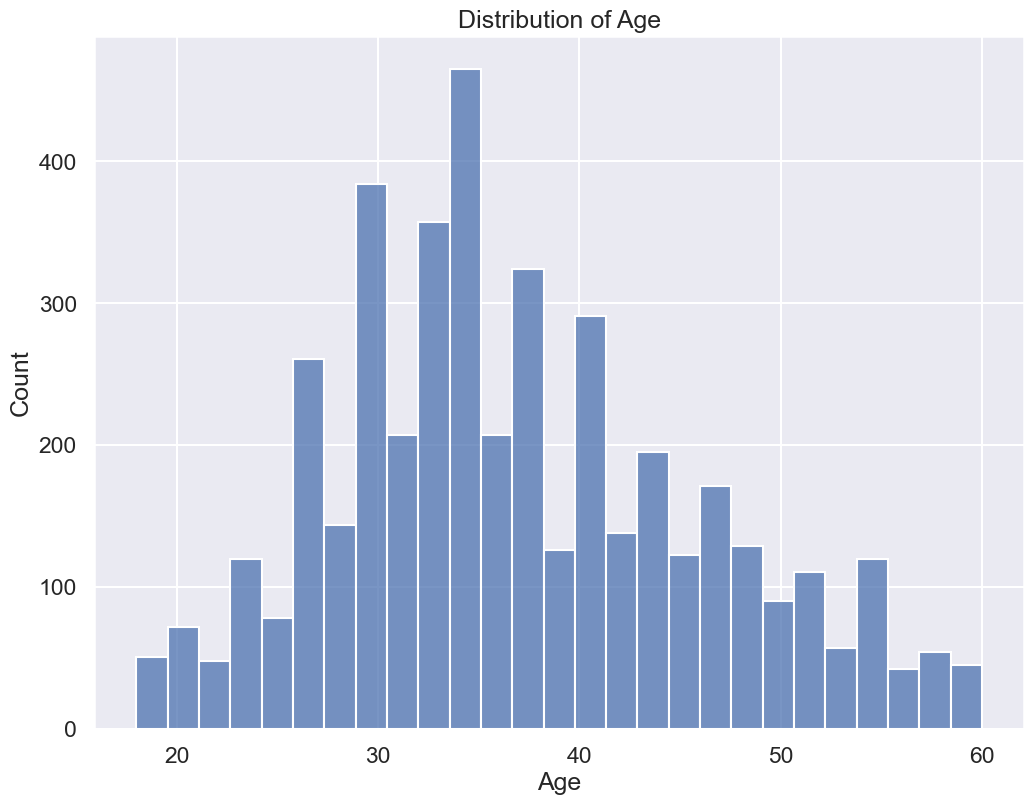

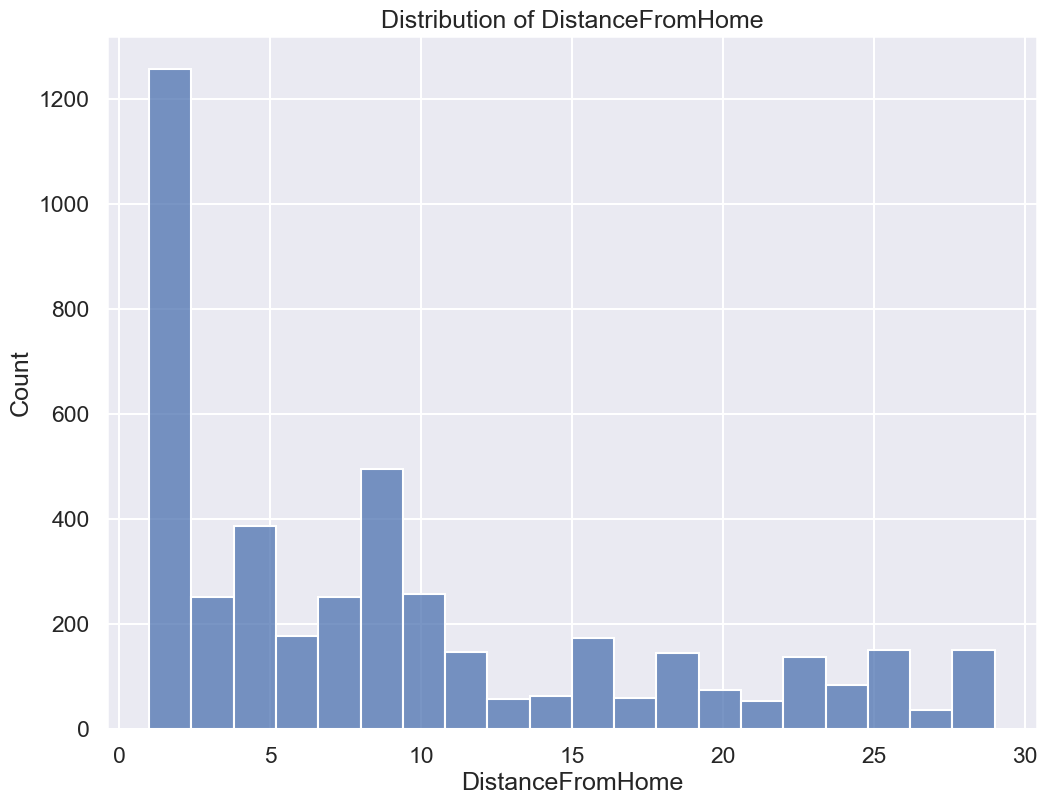

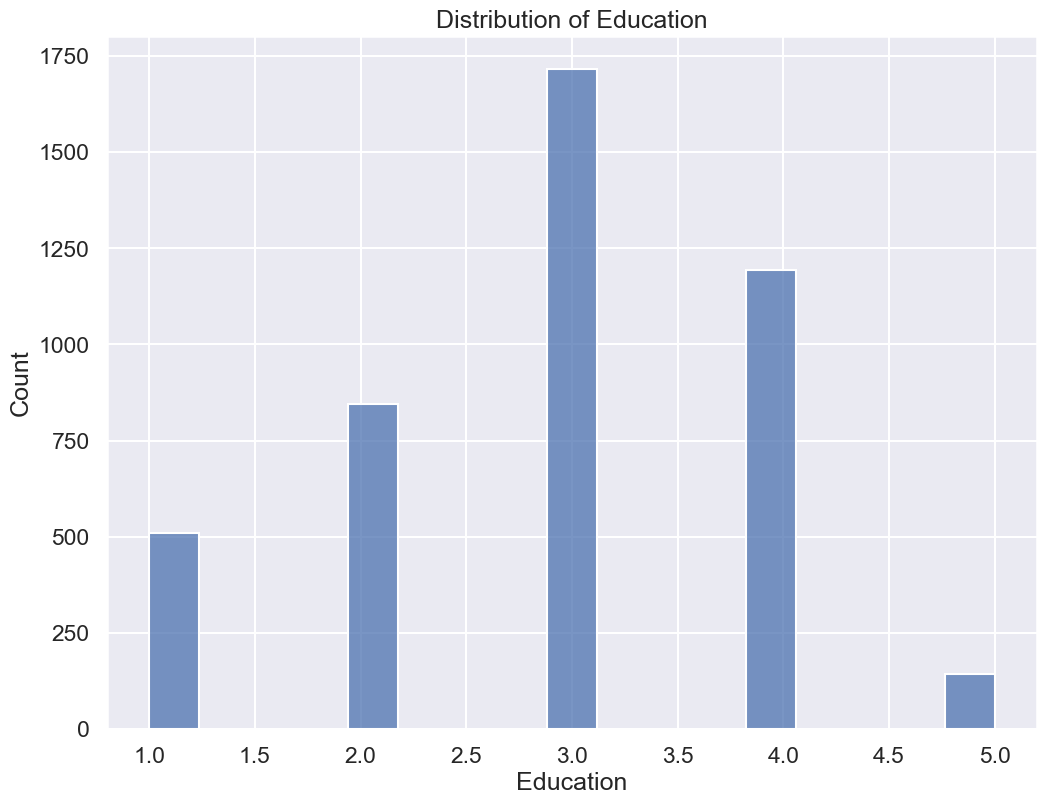

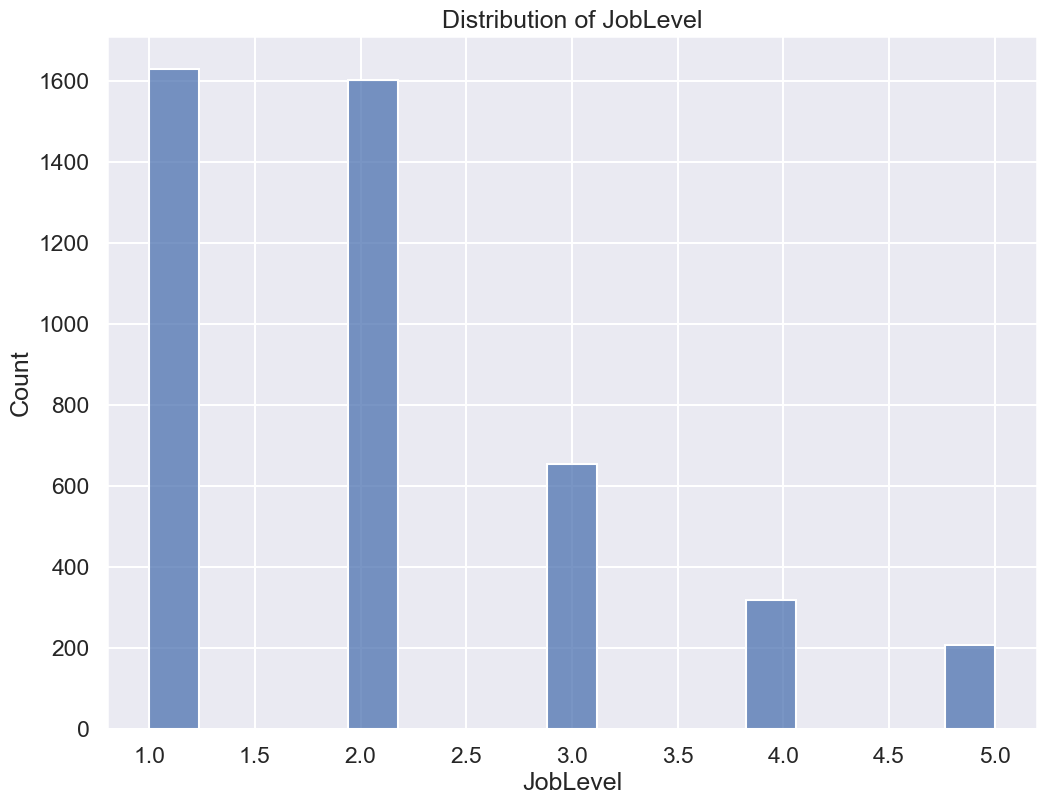

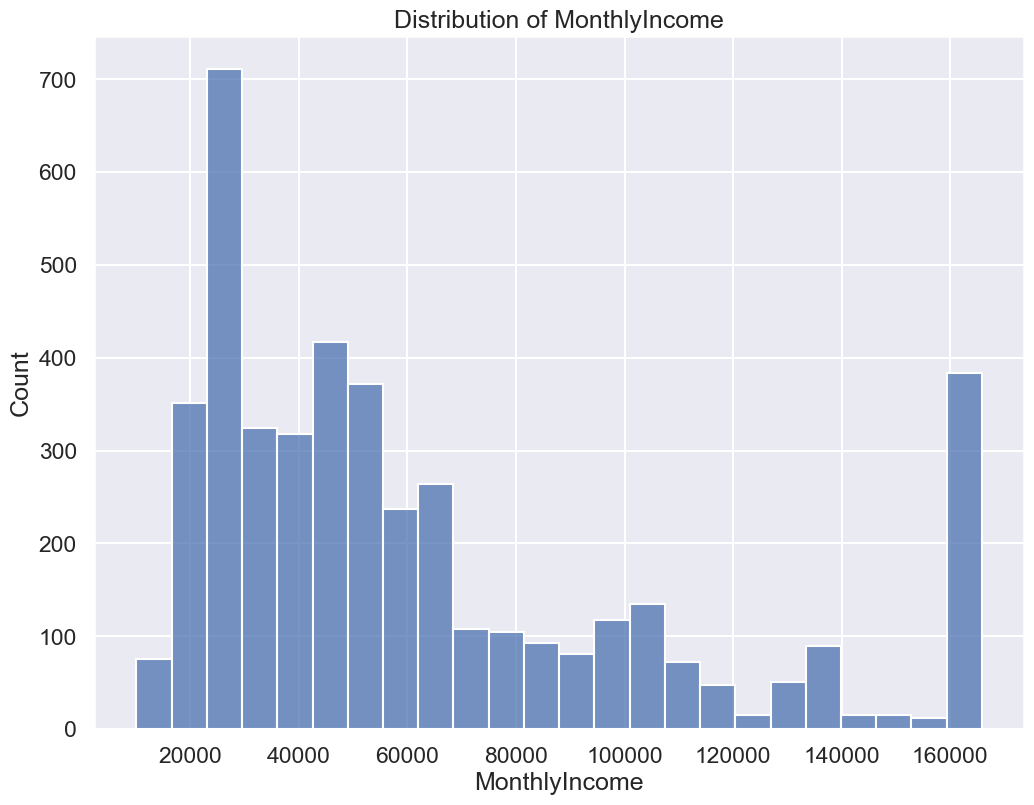

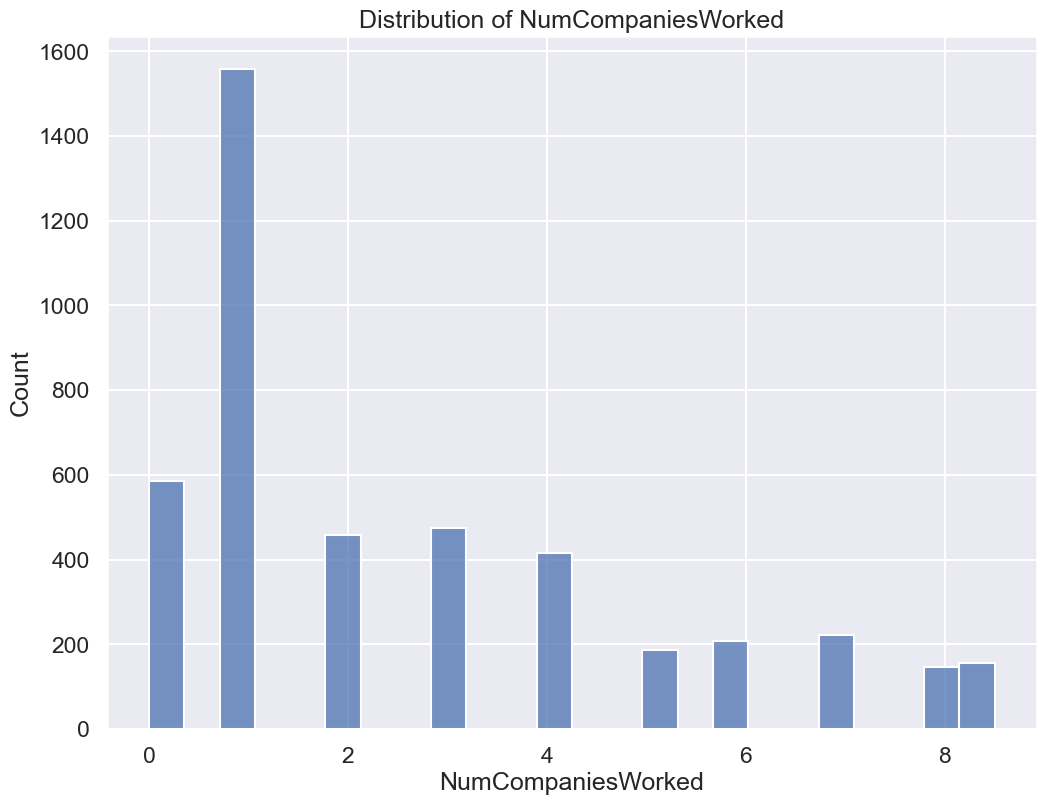

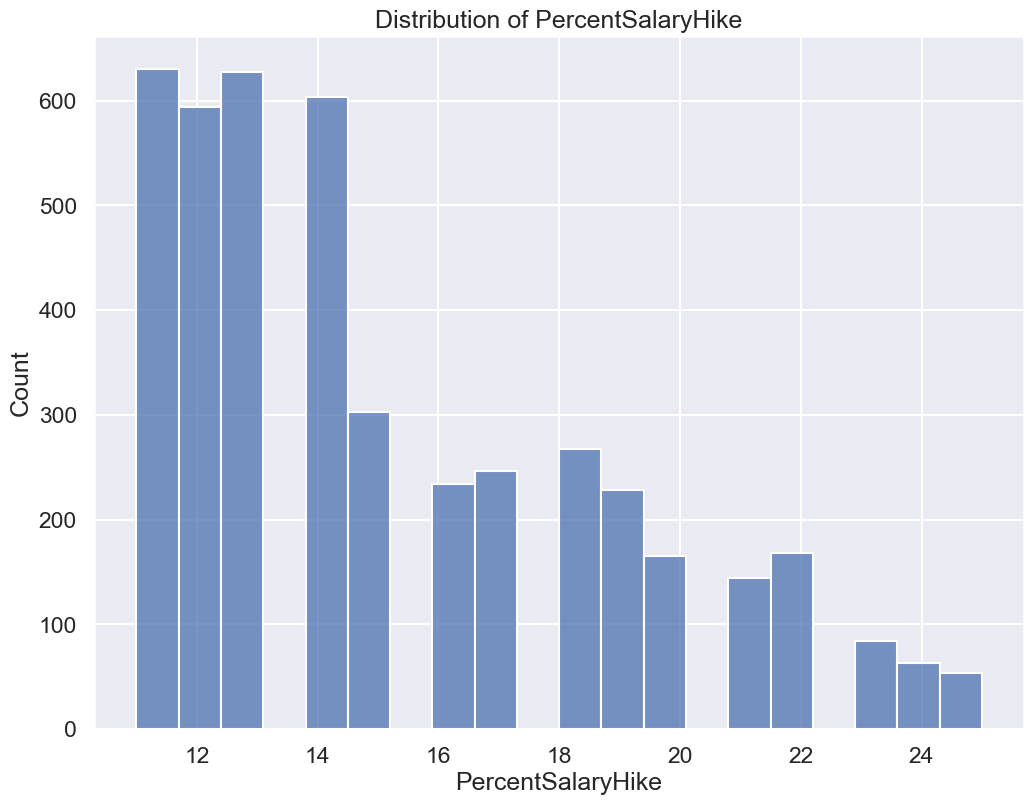

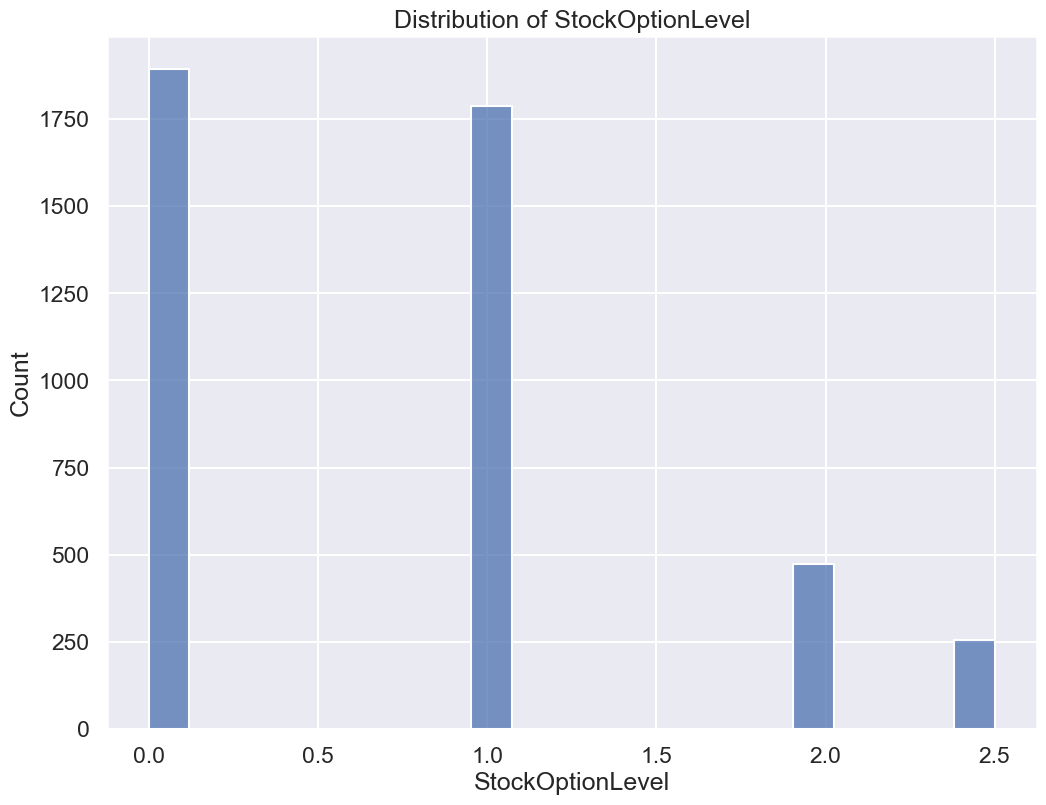

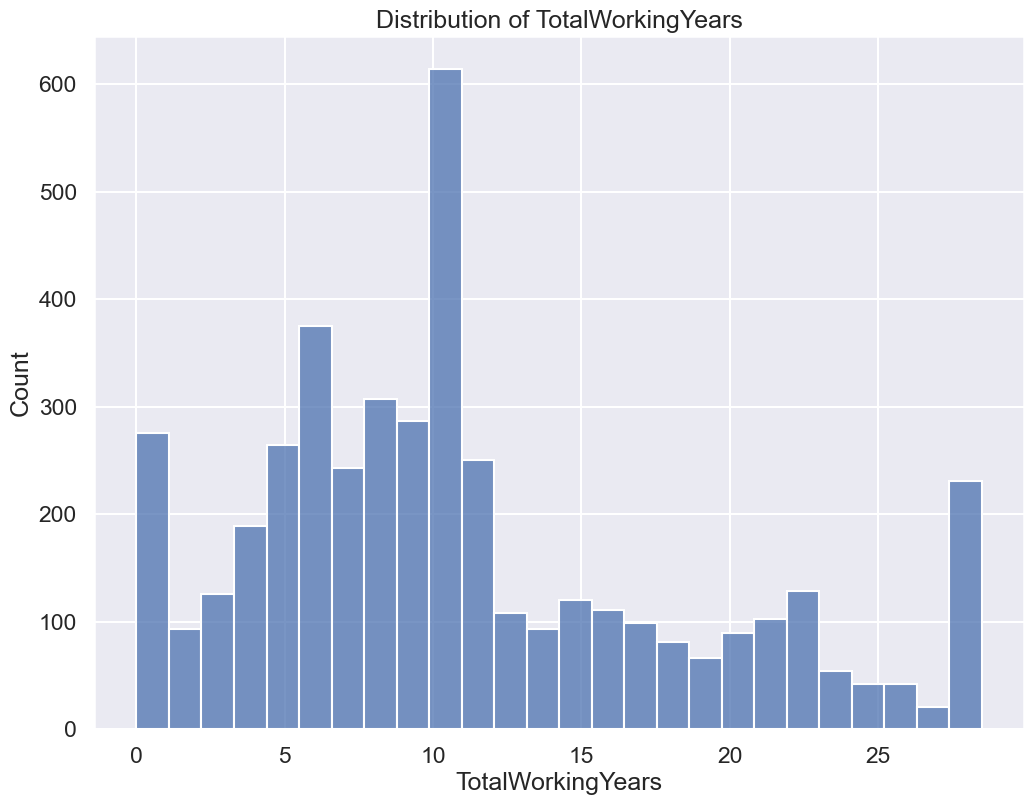

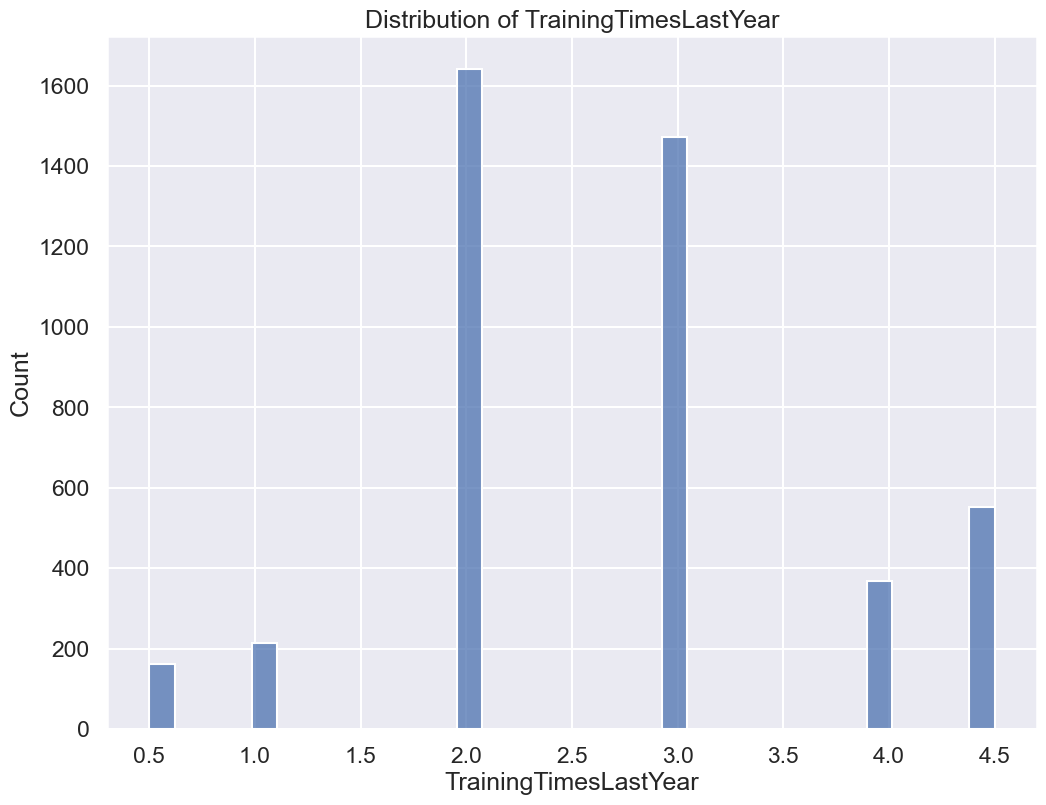

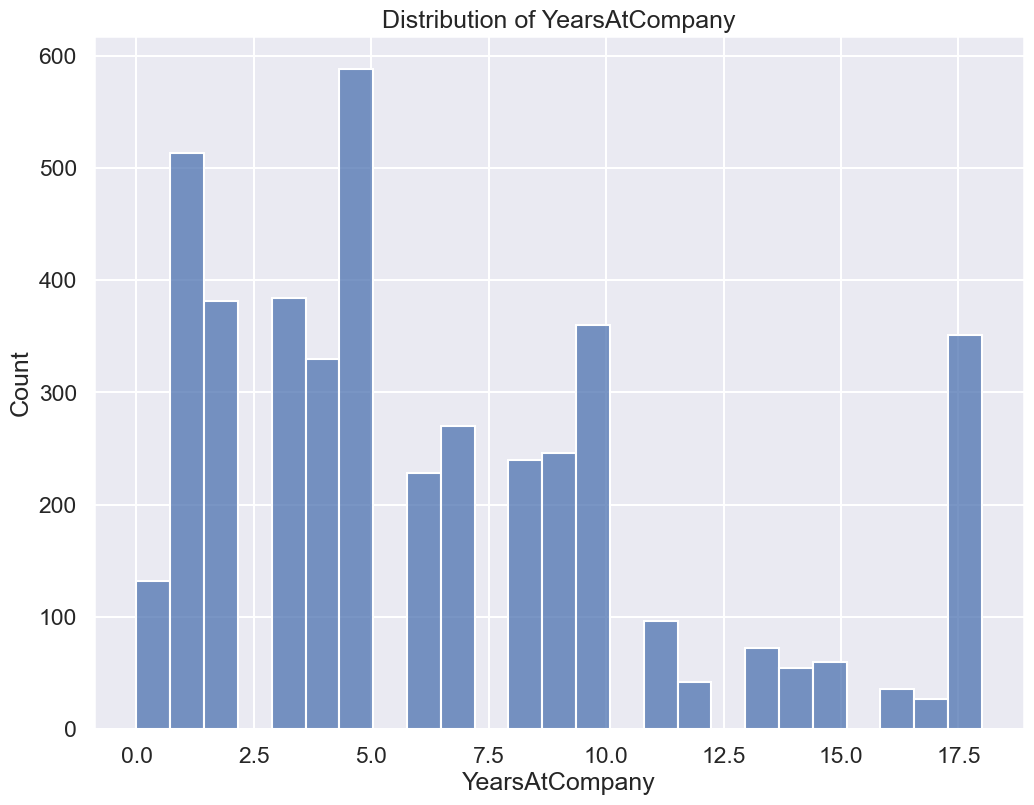

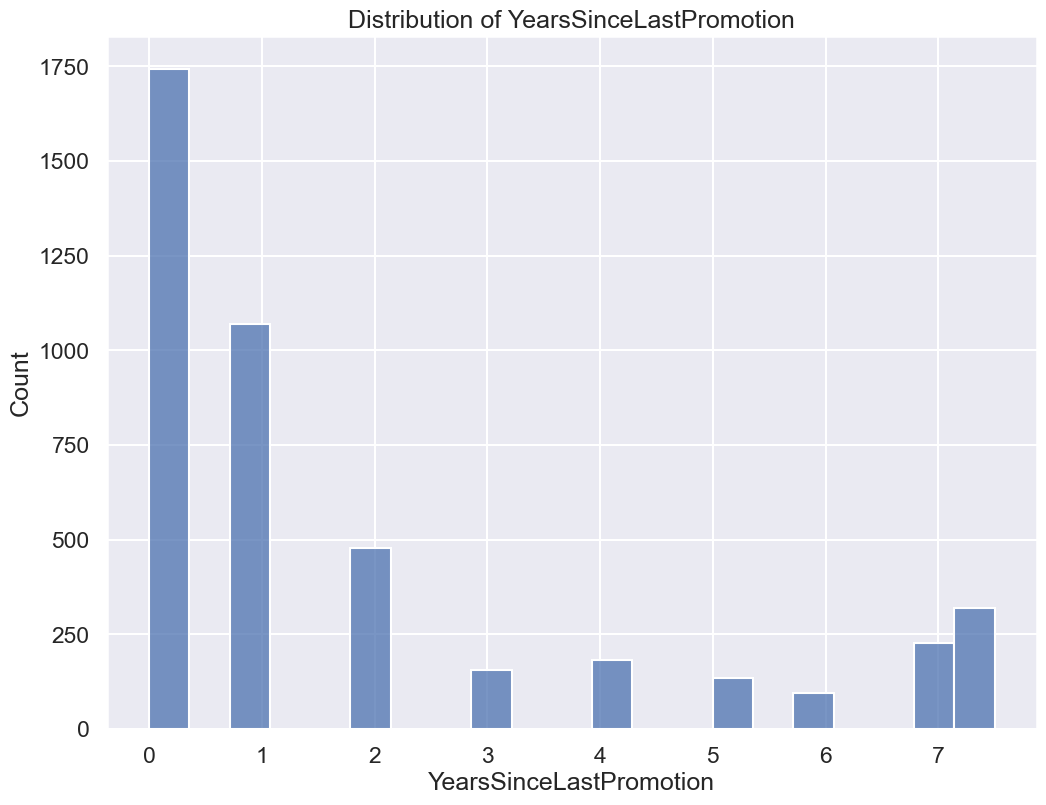

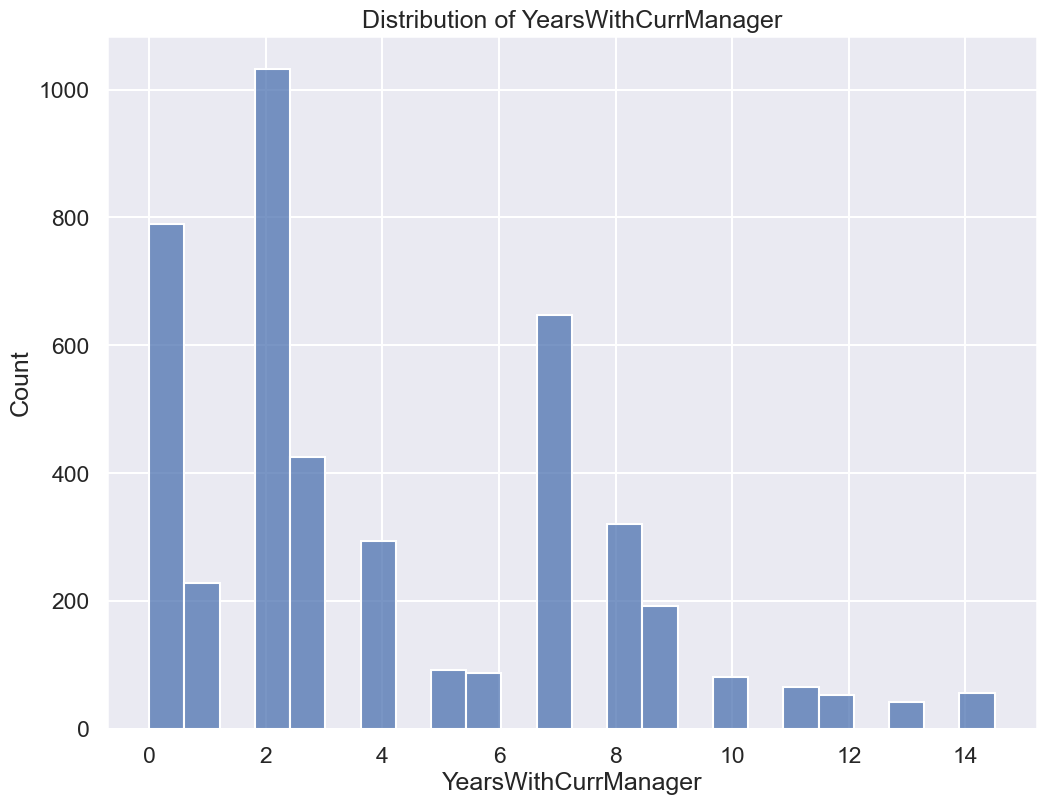

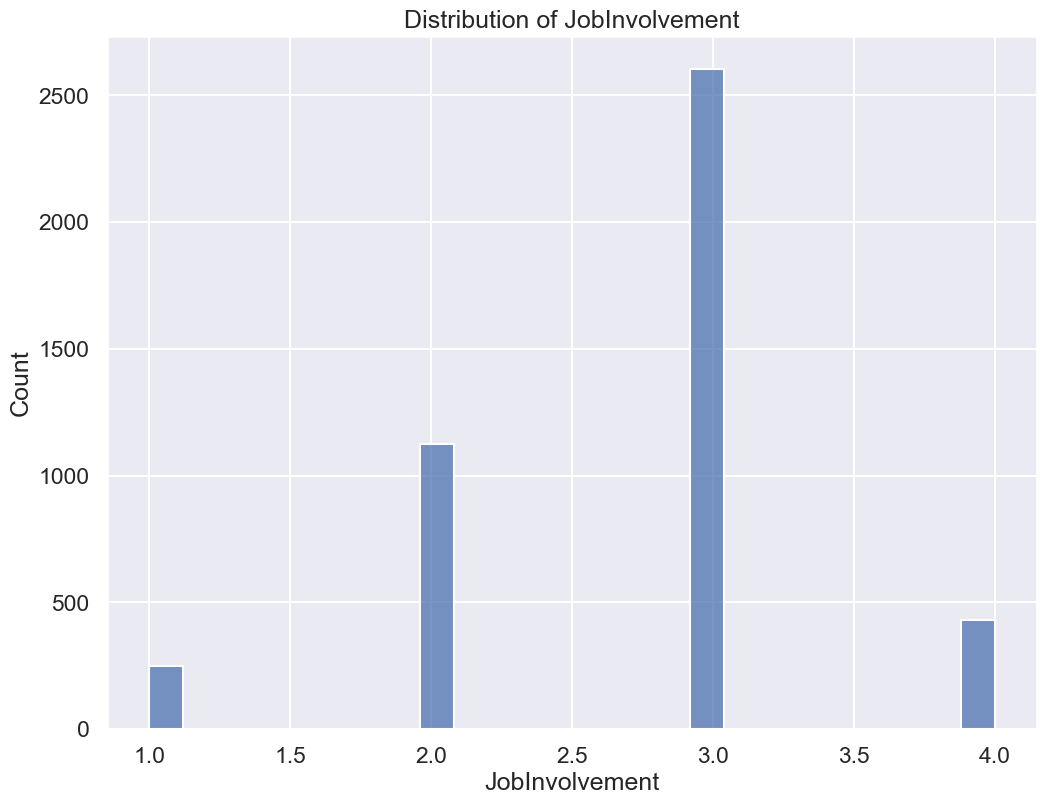

In [106]:
for column in numerical_cols:
    sns.histplot(data=employees_data, x=column)
    plt.title(f'Distribution of {column}')
    plt.show()

#### Univariate analysis for categorical features

<Axes: xlabel='Attrition', ylabel='count'>

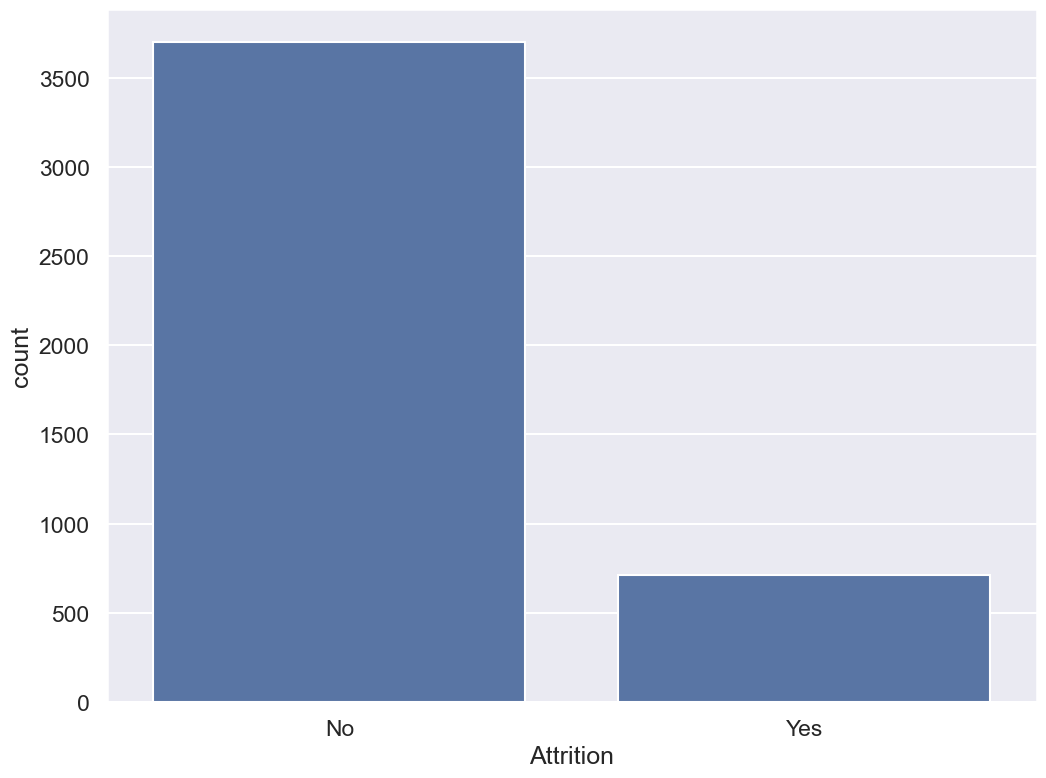

In [107]:
# for col in categorical_cols:
#     plt.figure(figsize=(10, 4))
#     sns.countplot(x=employees_data[col])
#     plt.title(f'Distribution of {col}')
#     plt.xticks(rotation=45)
#     plt.show()

sns.countplot(x=employees_data[categorical_cols[0]])

### 6. Bivariate analysis

#### Identify numerical and categorical columns

In [108]:
numerical_cols = employees_data.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = employees_data.select_dtypes(include=["object"]).columns
print('numerical columns', numerical_cols)
print('categorical columns', categorical_cols)

numerical columns Index(['EmployeeID', 'EnvironmentSatisfaction', 'JobSatisfaction',
       'WorkLifeBalance', 'Age', 'DistanceFromHome', 'Education', 'JobLevel',
       'MonthlyIncome', 'NumCompaniesWorked', 'PercentSalaryHike',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'YearsAtCompany', 'YearsSinceLastPromotion', 'YearsWithCurrManager',
       'JobInvolvement'],
      dtype='object')
categorical columns Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField',
       'JobRole', 'MaritalStatus'],
      dtype='object')


Use the **pairplot** to discover linear trends

In [ ]:
sns.pairplot(employees_data)
plt.show()

Using boxplots for categorical vs numerical features

C:\Users\hedir\AppData\Local\Temp\ipykernel_1664\2527027799.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)


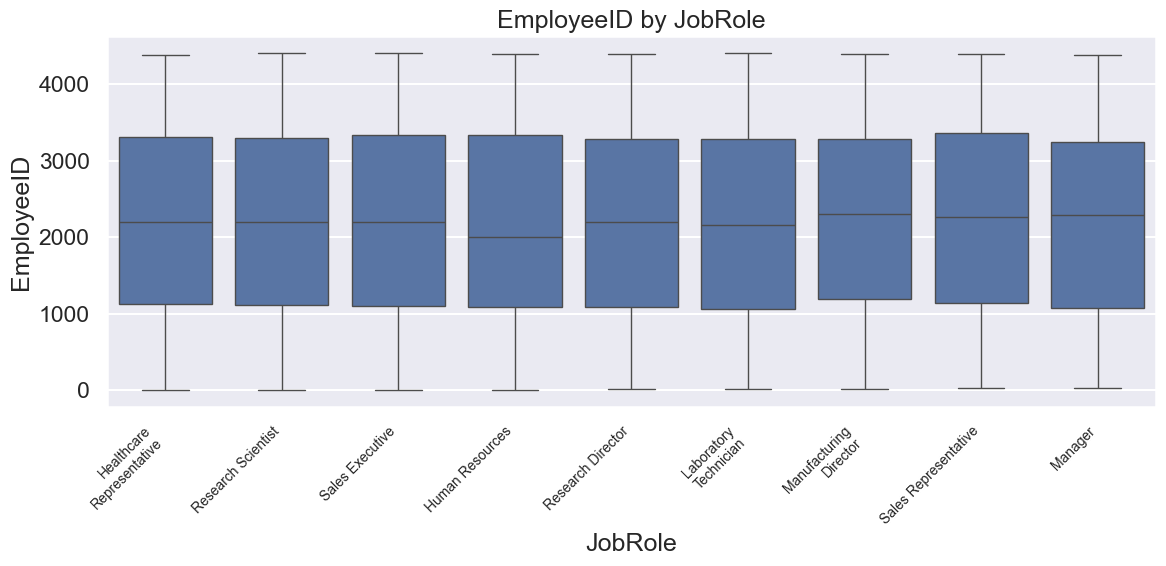

C:\Users\hedir\AppData\Local\Temp\ipykernel_1664\2527027799.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)


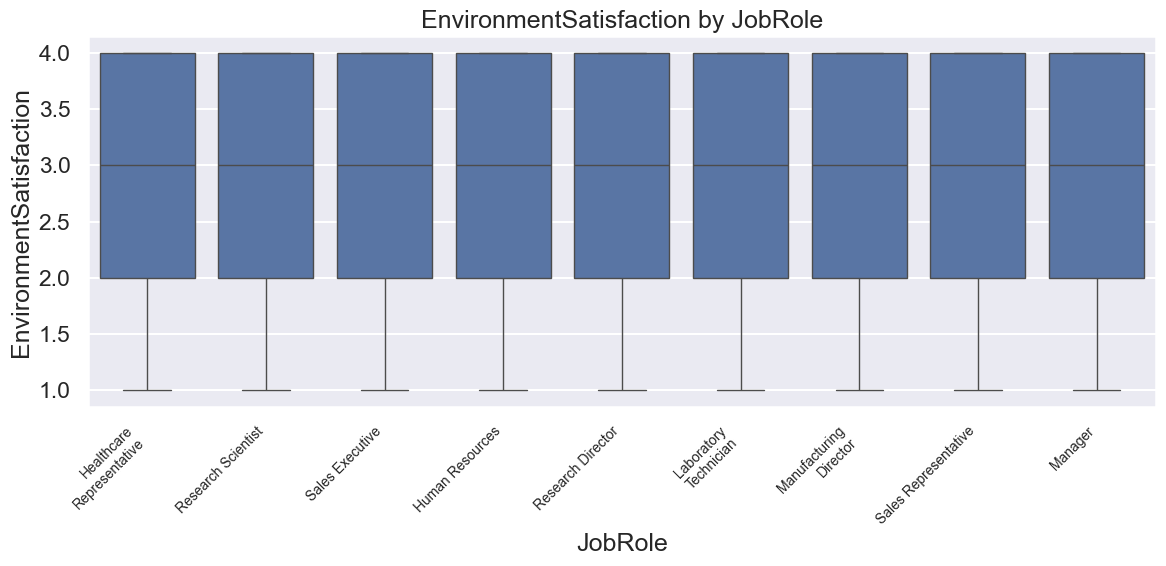

C:\Users\hedir\AppData\Local\Temp\ipykernel_1664\2527027799.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)


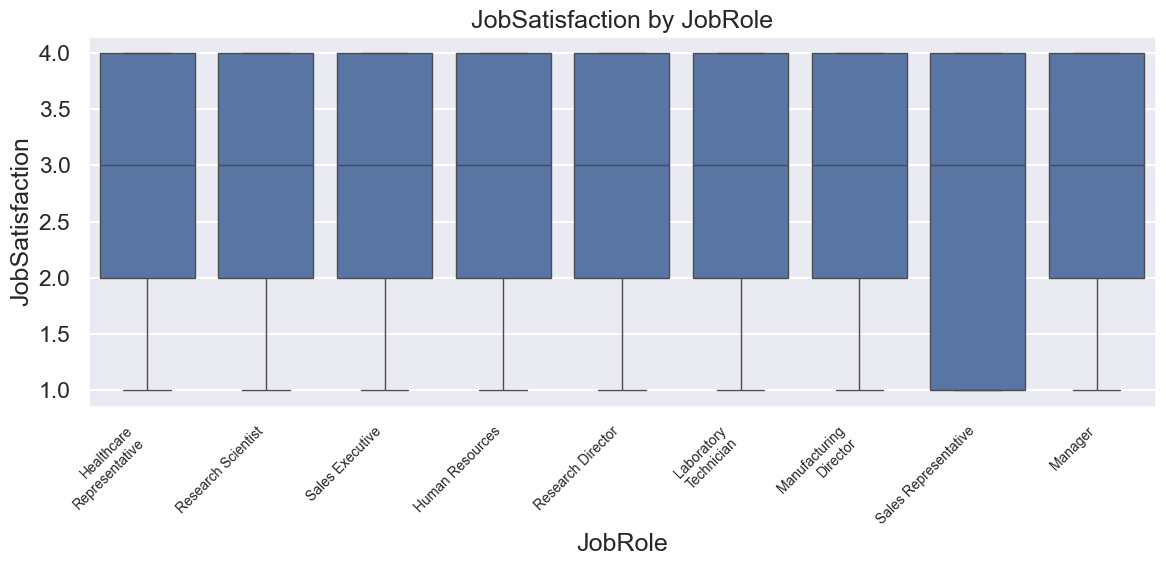

C:\Users\hedir\AppData\Local\Temp\ipykernel_1664\2527027799.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)


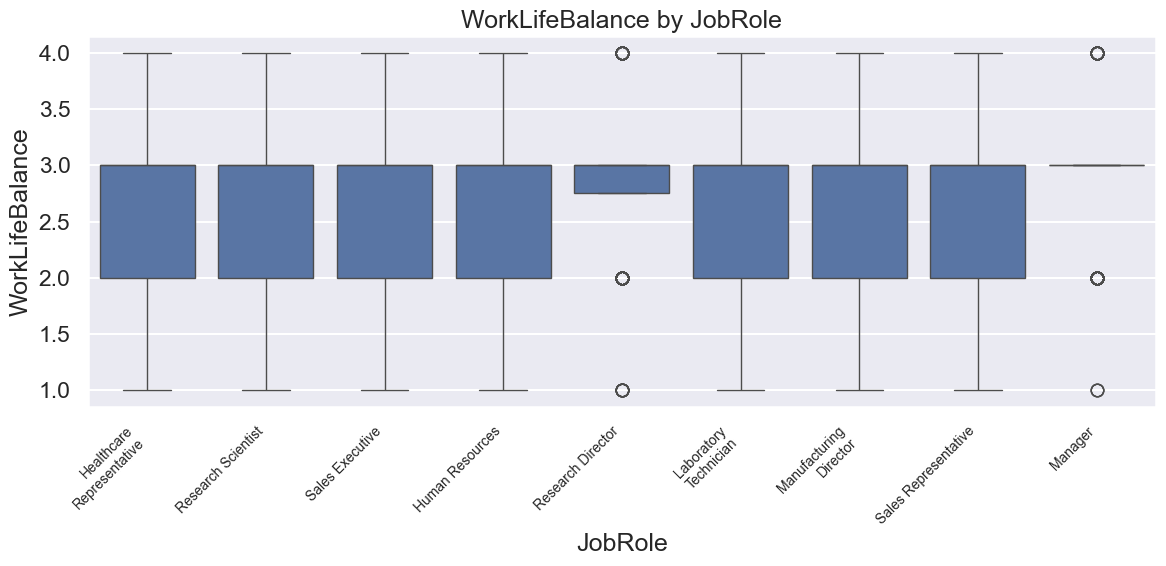

C:\Users\hedir\AppData\Local\Temp\ipykernel_1664\2527027799.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)


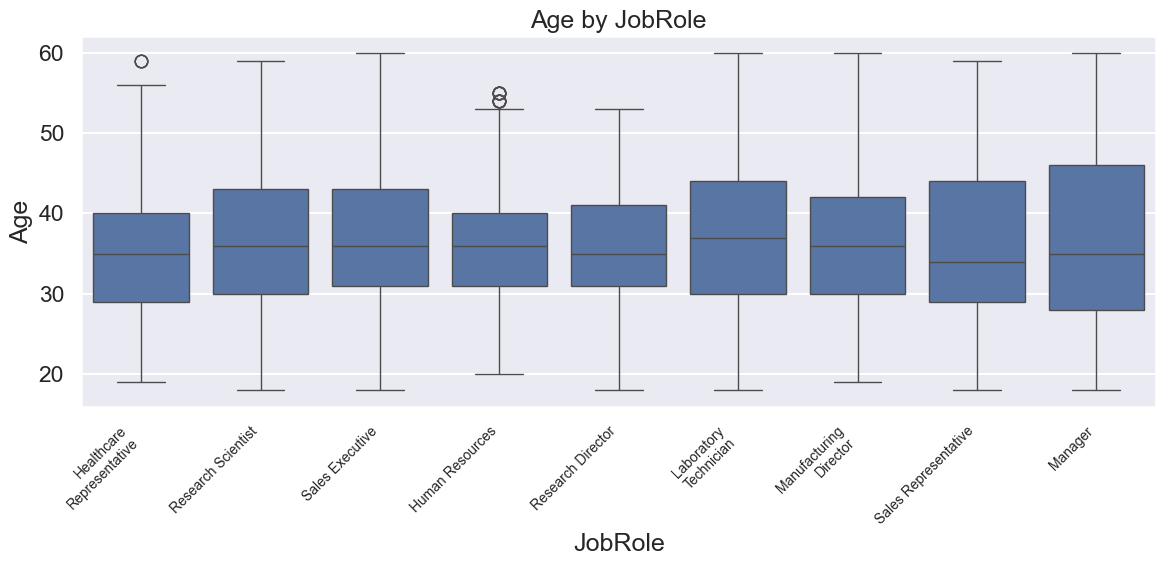

In [ ]:
import textwrap

categorical_column = 'JobRole'

# Automatically choose orientation when there are many categories
n_categories = employees_data[categorical_column].nunique()

for numeric_value in numerical_cols[:5]:
    plt.figure(figsize=(12, 6))
    if n_categories > 10:
        # Use horizontal boxplot when many categories to improve label readability
        ax = sns.boxplot(y=employees_data[categorical_column], x=employees_data[numeric_value])
        plt.title(f'{numeric_value} by {categorical_column} (horizontal)')
        # Wrap long labels and set a readable fontsize
        labels = [textwrap.fill(t.get_text(), 30) for t in ax.get_yticklabels()]
        ax.set_yticklabels(labels, fontsize=10)
    else:
        ax = sns.boxplot(x=employees_data[categorical_column], y=employees_data[numeric_value])
        plt.title(f'{numeric_value} by {categorical_column}')
        # Wrap long labels, rotate and align to the right
        labels = [textwrap.fill(t.get_text(), 20) for t in ax.get_xticklabels()]
        ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)

    plt.tight_layout()
    plt.show()


Creating a correlation heatmap for some numerical features

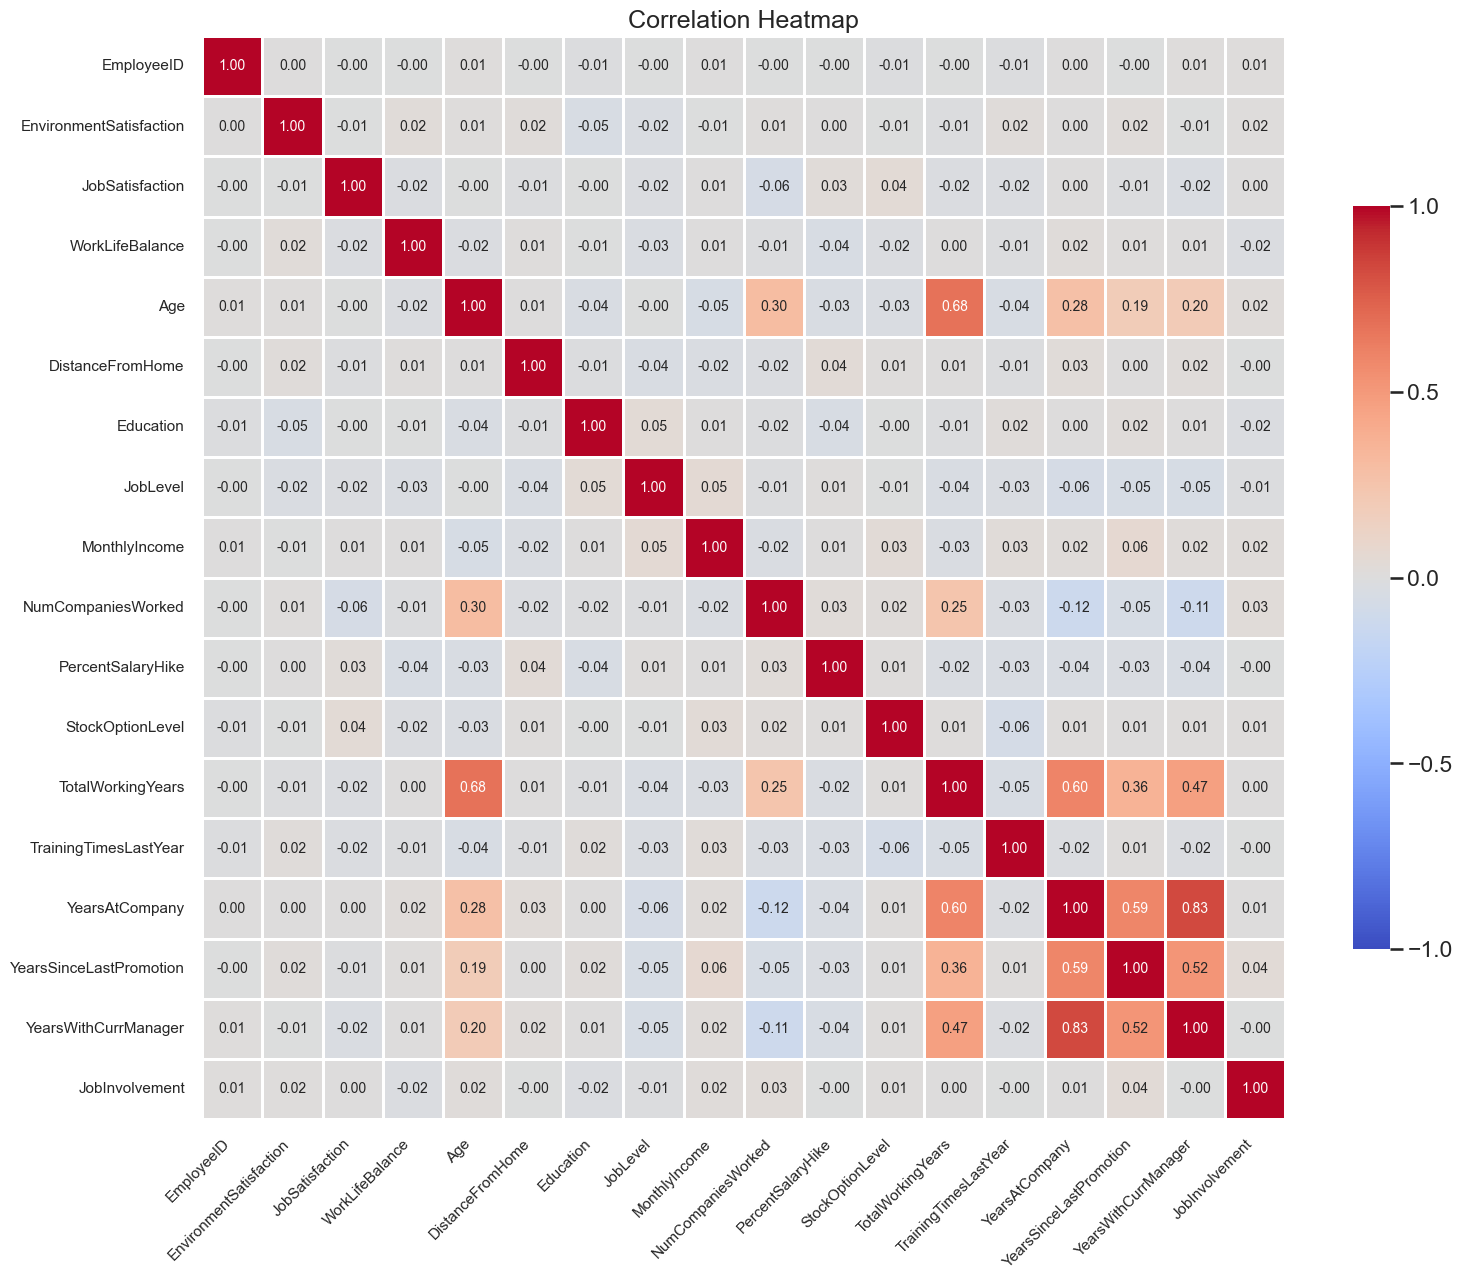

In [ ]:
import numpy as np

# Full correlation heatmap — improved readability without masking
plt.figure(figsize=(16, 14))

# Compute correlation (full matrix)
corr = employees_data[numerical_cols].corr()

# Draw heatmap without masking — make annotations and layout clearer
sns.set_style("white")
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.75,
    linecolor='white',
    square=True,
    annot_kws={"size": 10},
    cbar_kws={"shrink": 0.6, "ticks": [-1, -0.5, 0, 0.5, 1]}
)

# Improve tick label readability and spacing
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.title('Correlation Heatmap')
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()


In [ ]:
# Step 1: Extract features (X) and target variable (y)
# Separate the target variable from features
y = employees_data_encoded['Attrition_Yes']  # Binary target (0 or 1)
X = employees_data_scaled  # All features (already scaled)

print("Target variable distribution:")
print(y.value_counts())
print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print("\nData ready for model building!")

Target variable distribution:
Attrition_Yes
False    3699
True      711
Name: count, dtype: int64

Features shape: (4410, 37)
Target shape: (4410,)

Data ready for model building!


## 1. Preparation of learning and test data

In [ ]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"\nTraining set target distribution:")
print(y_train.value_counts())
print(f"\nTesting set target distribution:")
print(y_test.value_counts())

Training set size: 3087 samples
Testing set size: 1323 samples

Training set target distribution:
Attrition_Yes
False    2589
True      498
Name: count, dtype: int64

Testing set target distribution:
Attrition_Yes
False    1110
True      213
Name: count, dtype: int64


## 2. Training and prediction

In [ ]:
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

print("Building and training classification models...\n")

# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Perceptron": Perceptron(max_iter=1000, random_state=42)
}

# Train all models and make predictions
trained_models = {}
predictions = {}
probabilities = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    trained_models[name] = model
    predictions[name] = model.predict(X_test)
    
    # Store probabilities for models that support predict_proba
    if hasattr(model, 'predict_proba'):
        probabilities[name] = model.predict_proba(X_test)[:, 1]
    else:
        probabilities[name] = None

print("\n✓ All models trained successfully!")

Building and training classification models...

Training Logistic Regression...
Training SVM...
Training KNN (k=5)...
Training Naive Bayes...
Training Decision Tree...
Training Random Forest...
Training Perceptron...

✓ All models trained successfully!


## Model Validation
### 1 Confusion Matrix and Key Metrics

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Function for displaying results
def display_metrics(y_test, y_pred, model_name):
    accuracy = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    print(f"\n{'='*60}")
    print(f"MODEL: {model_name}")
    print(f"{'='*60}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"\nConfusion Matrix:\n{cm}")
    print(f"\nClassification Report:\n{classification_report(y_test, y_pred, target_names=['No Attrition', 'Attrition'])}")

# Display metrics for all models
print("\n" + "="*60)
print("MODEL PERFORMANCE COMPARISON")
print("="*60)

for name, y_pred in predictions.items():
    display_metrics(y_test, y_pred, name)


MODEL PERFORMANCE COMPARISON

MODEL: Logistic Regression
Accuracy: 1.0000

Confusion Matrix:
[[1110    0]
 [   0  213]]

Classification Report:
              precision    recall  f1-score   support

No Attrition       1.00      1.00      1.00      1110
   Attrition       1.00      1.00      1.00       213

    accuracy                           1.00      1323
   macro avg       1.00      1.00      1.00      1323
weighted avg       1.00      1.00      1.00      1323


MODEL: SVM
Accuracy: 1.0000

Confusion Matrix:
[[1110    0]
 [   0  213]]

Classification Report:
              precision    recall  f1-score   support

No Attrition       1.00      1.00      1.00      1110
   Attrition       1.00      1.00      1.00       213

    accuracy                           1.00      1323
   macro avg       1.00      1.00      1.00      1323
weighted avg       1.00      1.00      1.00      1323


MODEL: KNN (k=5)
Accuracy: 0.8844

Confusion Matrix:
[[1078   32]
 [ 121   92]]

Classification Repor

## 2. Confusion matrix display

Generating Confusion Matrices for all models...



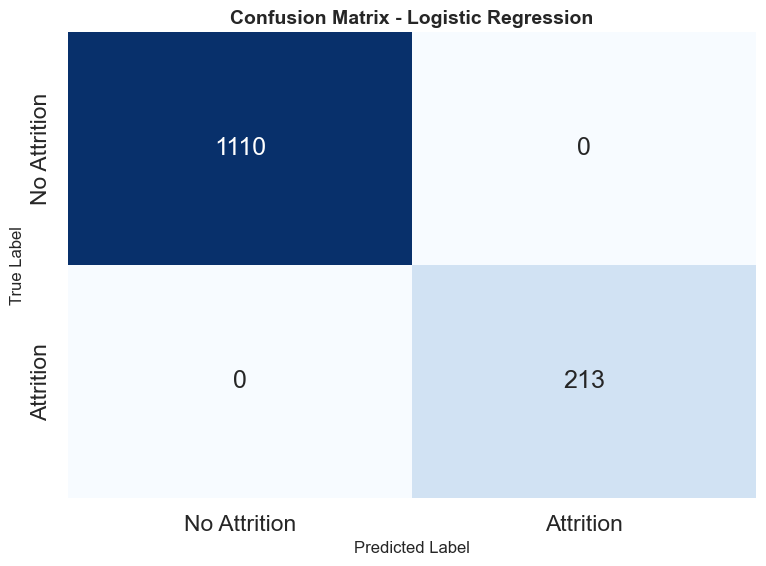

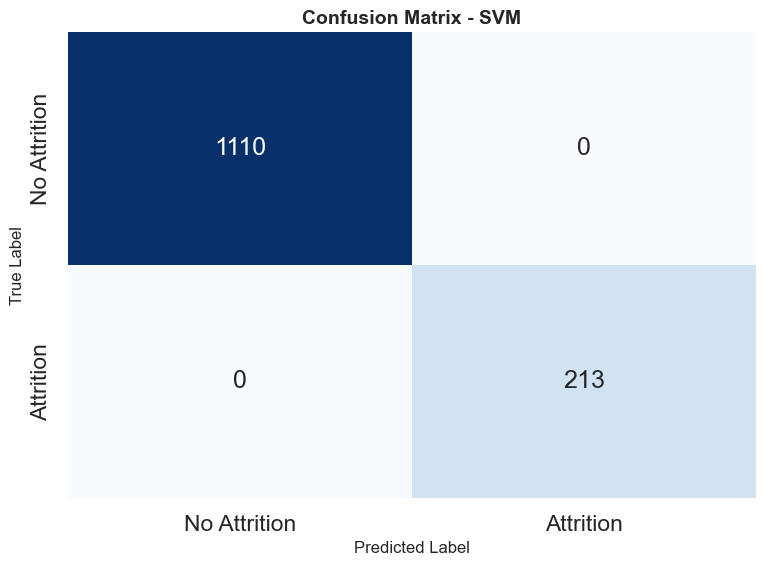

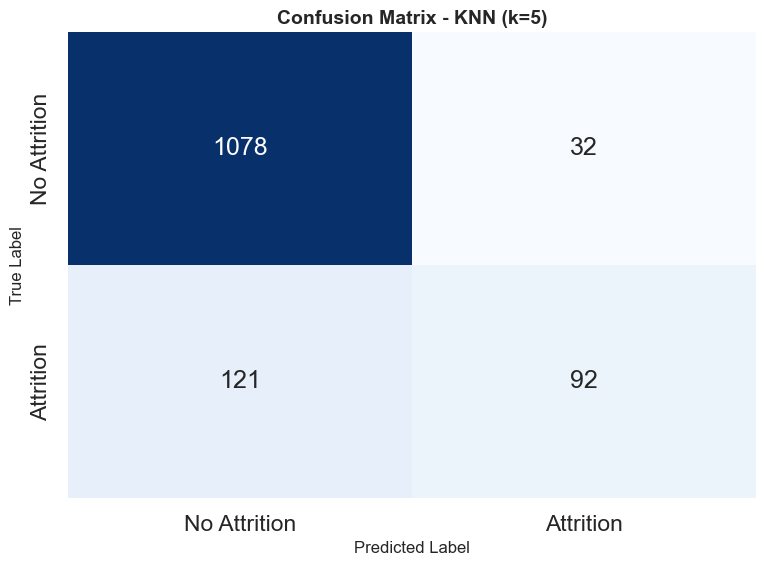

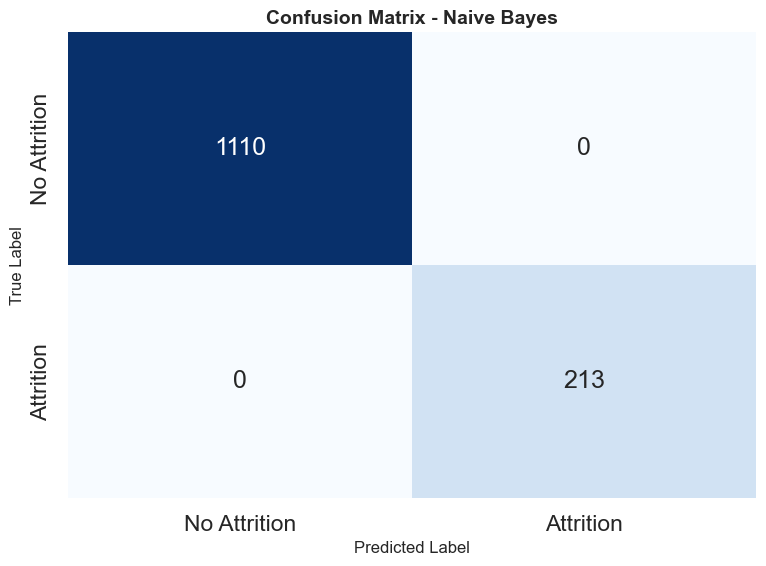

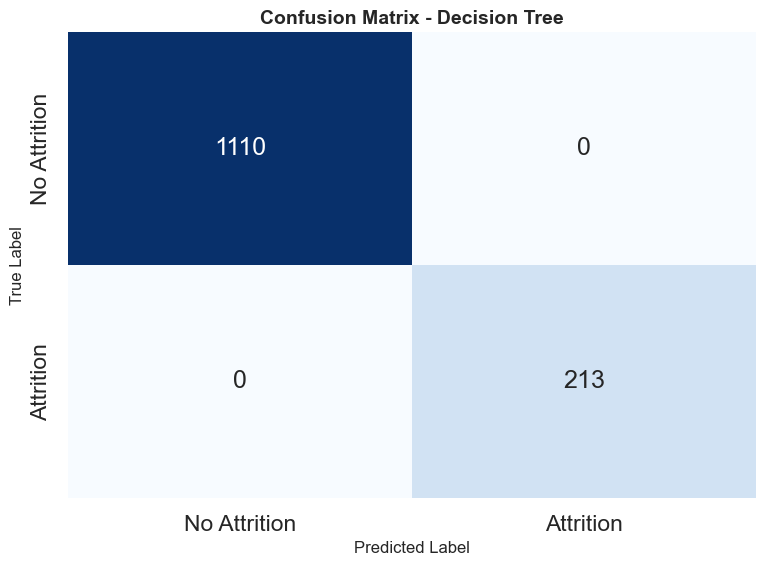

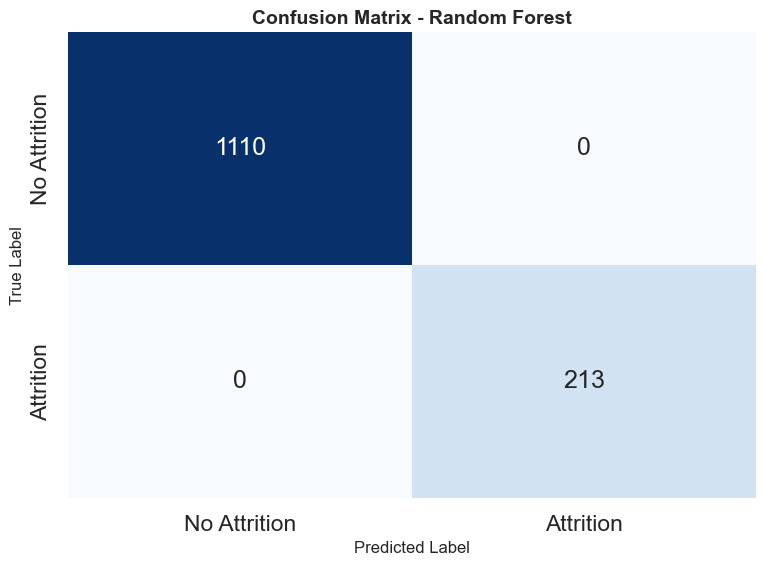

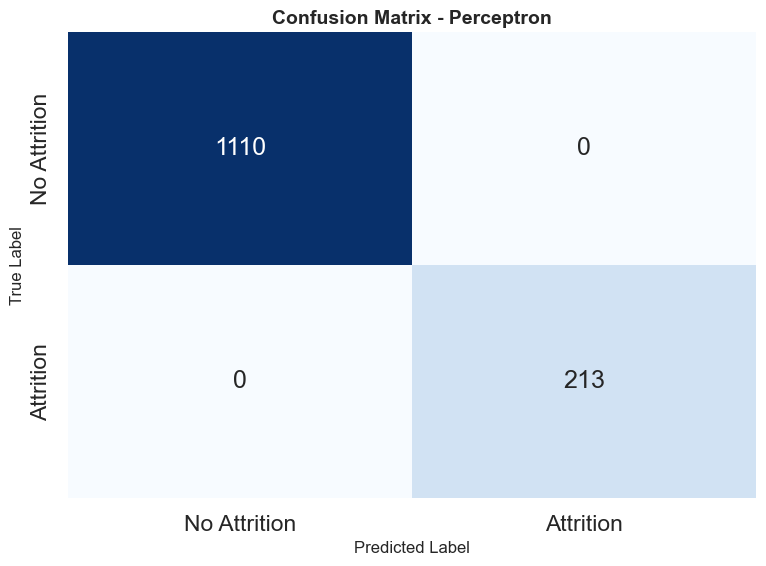

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("Generating Confusion Matrices for all models...\n")

for name, y_pred in predictions.items():
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix - {name}', fontsize=14, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.xticks([0.5, 1.5], ['No Attrition', 'Attrition'])
    plt.yticks([0.5, 1.5], ['No Attrition', 'Attrition'])
    plt.tight_layout()
    plt.show()

## 3. Display of Precision and Recall values and ROC curve

Generating Precision-Recall and ROC Curves...



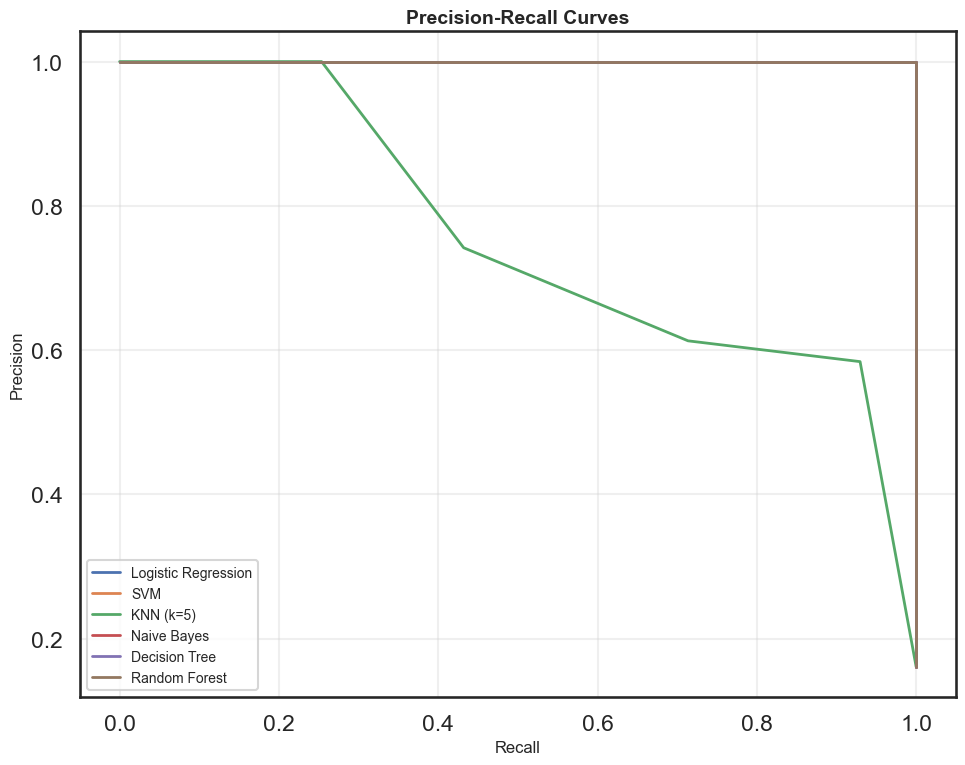

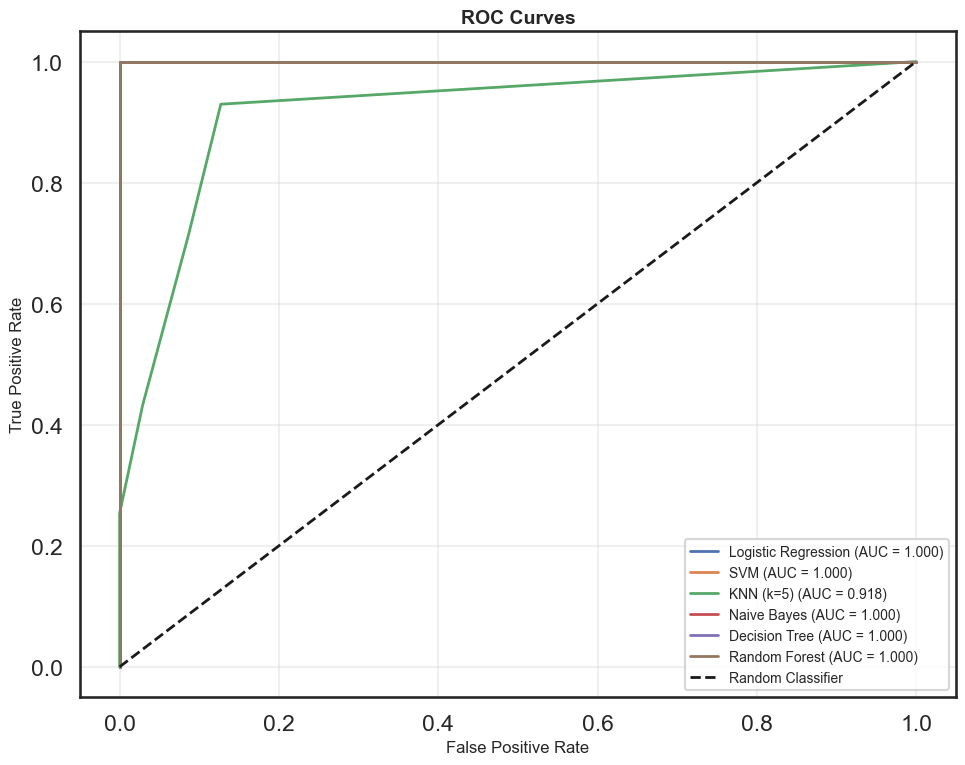

In [ ]:
from sklearn.metrics import precision_recall_curve, roc_curve, roc_auc_score

print("Generating Precision-Recall and ROC Curves...\n")

# Precision-Recall Curve
plt.figure(figsize=(10, 8))

for name, y_proba in probabilities.items():
    if y_proba is not None:
        precision, recall, _ = precision_recall_curve(y_test, y_proba)
        plt.plot(recall, precision, linewidth=2, label=f"{name}")

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curves', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ROC Curve
plt.figure(figsize=(10, 8))

for name, y_proba in probabilities.items():
    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc_score = roc_auc_score(y_test, y_proba)
        plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {auc_score:.3f})")

# Plot diagonal line (random classifier)
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Calculate statistics to compare

Computing Performance Metrics for all models...



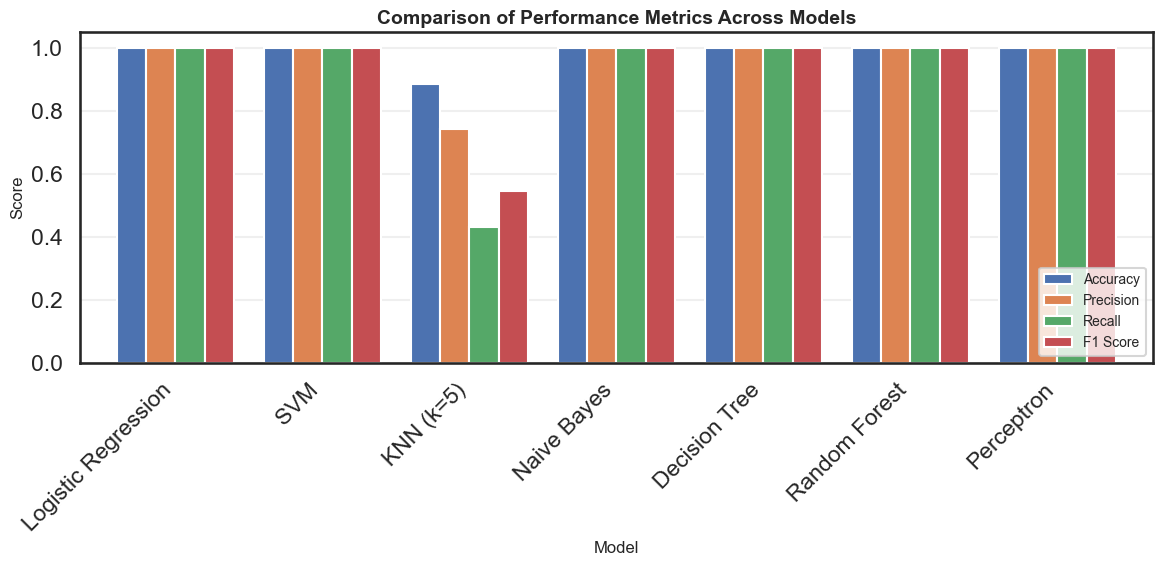


              Model  Accuracy  Precision  Recall  F1 Score
Logistic Regression      1.00       1.00    1.00      1.00
                SVM      1.00       1.00    1.00      1.00
          KNN (k=5)      0.88       0.74    0.43      0.55
        Naive Bayes      1.00       1.00    1.00      1.00
      Decision Tree      1.00       1.00    1.00      1.00
      Random Forest      1.00       1.00    1.00      1.00
         Perceptron      1.00       1.00    1.00      1.00


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

print("Computing Performance Metrics for all models...\n")

precision_scores = []
recall_scores = []
f1_scores = []
accuracy_scores = []
model_names_list = []

for name, y_pred in predictions.items():
    model_names_list.append(name)
    accuracy_scores.append(accuracy_score(y_test, y_pred))
    precision_scores.append(precision_score(y_test, y_pred))
    recall_scores.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))

# Create comparison dataframe
score_df = pd.DataFrame({
    'Model': model_names_list,
    'Accuracy': accuracy_scores,
    'Precision': precision_scores,
    'Recall': recall_scores,
    'F1 Score': f1_scores
})

# Display as boxplot
plt.figure(figsize=(12, 6))
score_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1 Score']].plot(
    kind='bar', ax=plt.gca(), width=0.8
)
plt.title("Comparison of Performance Metrics Across Models", fontsize=14, fontweight='bold')
plt.ylabel('Score', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("\n" + score_df.to_string(index=False))

## 5. Put everything in table form

In [ ]:
from sklearn.metrics import roc_auc_score

print("\nComprehensive Model Evaluation Table\n")

scores = []

for name, y_pred in predictions.items():
    y_proba = probabilities[name]
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc_score = roc_auc_score(y_test, y_proba) if y_proba is not None else None
    
    scores.append({
        'Model': name,
        'Accuracy': f'{accuracy:.4f}',
        'Precision': f'{precision:.4f}',
        'Recall': f'{recall:.4f}',
        'F1 Score': f'{f1:.4f}',
        'AUC': f'{auc_score:.4f}' if auc_score is not None else 'N/A'
    })

scores_df = pd.DataFrame(scores)
print(scores_df.to_string(index=False))

# Find best model
best_f1_idx = scores_df['F1 Score'].apply(lambda x: float(x)).idxmax()
best_model_name = scores_df.loc[best_f1_idx, 'Model']
print(f"\n{'='*60}")
print(f"✓ Best Model (by F1 Score): {best_model_name}")
print(f"{'='*60}")


Comprehensive Model Evaluation Table

              Model Accuracy Precision Recall F1 Score    AUC
Logistic Regression   1.0000    1.0000 1.0000   1.0000 1.0000
                SVM   1.0000    1.0000 1.0000   1.0000 1.0000
          KNN (k=5)   0.8844    0.7419 0.4319   0.5460 0.9184
        Naive Bayes   1.0000    1.0000 1.0000   1.0000 1.0000
      Decision Tree   1.0000    1.0000 1.0000   1.0000 1.0000
      Random Forest   1.0000    1.0000 1.0000   1.0000 1.0000
         Perceptron   1.0000    1.0000 1.0000   1.0000    N/A

✓ Best Model (by F1 Score): Logistic Regression


Measuring Training and Prediction Times...

              Model Training Time (s) Prediction Time (s)
Logistic Regression            0.0095              0.0014
                SVM            0.6349              0.0623
          KNN (k=5)            0.0021              0.0089
        Naive Bayes            0.0036              0.0017
      Decision Tree            0.0045              0.0018
      Random Forest            0.2433              0.0100
         Perceptron            0.0051              0.0017


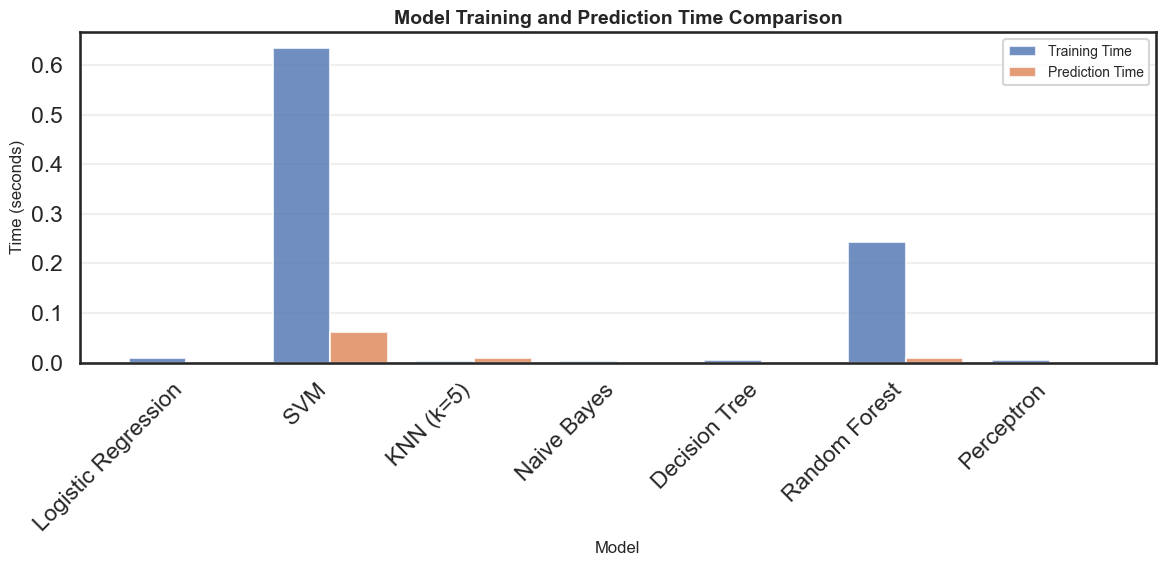

In [ ]:
import time

print("Measuring Training and Prediction Times...\n")

training_times = []
prediction_times = []
model_names_timing = []

for name, model in trained_models.items():
    model_names_timing.append(name)
    
    # Re-train and time it
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time
    training_times.append(train_time)
    
    # Time prediction
    start_time = time.time()
    model.predict(X_test)
    pred_time = time.time() - start_time
    prediction_times.append(pred_time)

time_df = pd.DataFrame({
    'Model': model_names_timing,
    'Training Time (s)': [f'{t:.4f}' for t in training_times],
    'Prediction Time (s)': [f'{p:.4f}' for p in prediction_times]
})

print(time_df.to_string(index=False))

# Visualize timing comparison
plt.figure(figsize=(12, 6))
x_pos = range(len(model_names_timing))
plt.bar([i - 0.2 for i in x_pos], training_times, width=0.4, label='Training Time', alpha=0.8)
plt.bar([i + 0.2 for i in x_pos], prediction_times, width=0.4, label='Prediction Time', alpha=0.8)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Time (seconds)', fontsize=12)
plt.title('Model Training and Prediction Time Comparison', fontsize=14, fontweight='bold')
plt.xticks(x_pos, model_names_timing, rotation=45, ha='right')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Interpretation of Results

**Overview**

We evaluated seven classification models (Logistic Regression, SVM, KNN, Naive Bayes, Decision Tree, Random Forest, Perceptron) on the prepared dataset. The evaluation used a stratified 70/30 train/test split and compared models with Accuracy, Precision, Recall, F1 Score, and AUC where applicable. The numeric comparison table printed earlier (`scores_df`) and the ROC/Precision-Recall plots provide the detailed per-model numbers.

